#Importing the Libraries
These might be necessary to visualize the data and train models.

In [1]:
!nvidia-smi

Fri Feb 21 21:14:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   44C    P3             37W /  280W |    1952MiB /   8192MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# importing libraries and installing them if they are not available


import pandas as pd

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import PCA

from sklearn.metrics import fbeta_score, make_scorer

import statsmodels.stats.api as sms

from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

from statsmodels.tools.tools import add_constant

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn import tree

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import RandomizedSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.metrics import(
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)
import warnings
warnings.filterwarnings('ignore')

## Importing the CSV file from Google Drive

In [3]:
pip install google.colab

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement google.colab (from versions: none)
ERROR: No matching distribution found for google.colab
You should consider upgrading via the 'C:\Users\abdul\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [ ]:
# Mounting the Drive if using colab
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Finding where the CSV is locally
path = "PATH TO CSV"
data = pd.read_csv(path)
df = data.copy()

# Data Overview


In [7]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [8]:
df.tail()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [9]:
df.shape

(148670, 34)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [11]:
df.duplicated().any()

np.False_

In [12]:
percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'percent_missing': percent_missing})
missing_value_df

,percent_missing
ID,0.000000
year,0.000000
loan_limit,2.249277
Gender,0.000000
approv_in_adv,0.610749
loan_type,0.000000
loan_purpose,0.090133
Credit_Worthiness,0.000000
open_credit,0.000000
business_or_commercial,0.000000


All the 'Object' types in this data set are in reality categories for each user.
Therefore, we will be:
- Putting all the Object types into a list to change the label to category.
- Adding the Status to that list, since it is also a category, not actually an int.

In [13]:
cols = df.select_dtypes(['object']).columns.tolist()
cols.append('Status')

In [14]:
cols

['loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'Neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'construction_type',
 'occupancy_type',
 'Secured_by',
 'total_units',
 'credit_type',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'Region',
 'Security_Type',
 'Status']

In [15]:
for col in cols:
  df[col] = df[col].astype('category')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   ID                         148670 non-null  int64   
 1   year                       148670 non-null  int64   
 2   loan_limit                 145326 non-null  category
 3   Gender                     148670 non-null  category
 4   approv_in_adv              147762 non-null  category
 5   loan_type                  148670 non-null  category
 6   loan_purpose               148536 non-null  category
 7   Credit_Worthiness          148670 non-null  category
 8   open_credit                148670 non-null  category
 9   business_or_commercial     148670 non-null  category
 10  loan_amount                148670 non-null  int64   
 11  rate_of_interest           112231 non-null  float64 
 12  Interest_rate_spread       112031 non-null  float64 
 13  Upfront_charge

Changed the types successfuly

Now let's get a quick Summary of the Statistics of the entire df

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


In [21]:
pd.set_option('display.max_columns', None)

In [24]:
# setting df.describe to show all column features
df.describe(include = 'all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,148670.0,NaN,NaN,NaN,99224.5,42917.476598,24890.0,62057.25,99224.5,136391.75,173559.0
year,148670.0,NaN,NaN,NaN,2019.0,0.0,2019.0,2019.0,2019.0,2019.0,2019.0
loan_limit,145326,2,cf,135348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,148670,4,Male,42346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
approv_in_adv,147762,2,nopre,124621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_type,148670,3,type1,113173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_purpose,148536,4,p3,55934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit_Worthiness,148670,2,l1,142344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
open_credit,148670,2,nopc,148114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_or_commercial,148670,2,nob/c,127908,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Observations looking at the Summary:
-
-

Next is the different categories in each type:

In [26]:
for col in cols:
  print(f"{col}: {df[col].unique()}")

loan_limit: ['cf', NaN, 'ncf']
Categories (2, object): ['cf', 'ncf']
Gender: ['Sex Not Available', 'Male', 'Joint', 'Female']
Categories (4, object): ['Female', 'Joint', 'Male', 'Sex Not Available']
approv_in_adv: ['nopre', 'pre', NaN]
Categories (2, object): ['nopre', 'pre']
loan_type: ['type1', 'type2', 'type3']
Categories (3, object): ['type1', 'type2', 'type3']
loan_purpose: ['p1', 'p4', 'p3', 'p2', NaN]
Categories (4, object): ['p1', 'p2', 'p3', 'p4']
Credit_Worthiness: ['l1', 'l2']
Categories (2, object): ['l1', 'l2']
open_credit: ['nopc', 'opc']
Categories (2, object): ['nopc', 'opc']
business_or_commercial: ['nob/c', 'b/c']
Categories (2, object): ['b/c', 'nob/c']
Neg_ammortization: ['not_neg', 'neg_amm', NaN]
Categories (2, object): ['neg_amm', 'not_neg']
interest_only: ['not_int', 'int_only']
Categories (2, object): ['int_only', 'not_int']
lump_sum_payment: ['not_lpsm', 'lpsm']
Categories (2, object): ['lpsm', 'not_lpsm']
construction_type: ['sb', 'mh']
Categories (2, object)

# Exploratory Data Analysis (EDA) and Visualization

# Univariate Analysis

In [28]:
def histogram_boxplot(data, feature, figsize=(9, 8), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (9,8))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.15, 0.85)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )
    plt.show()

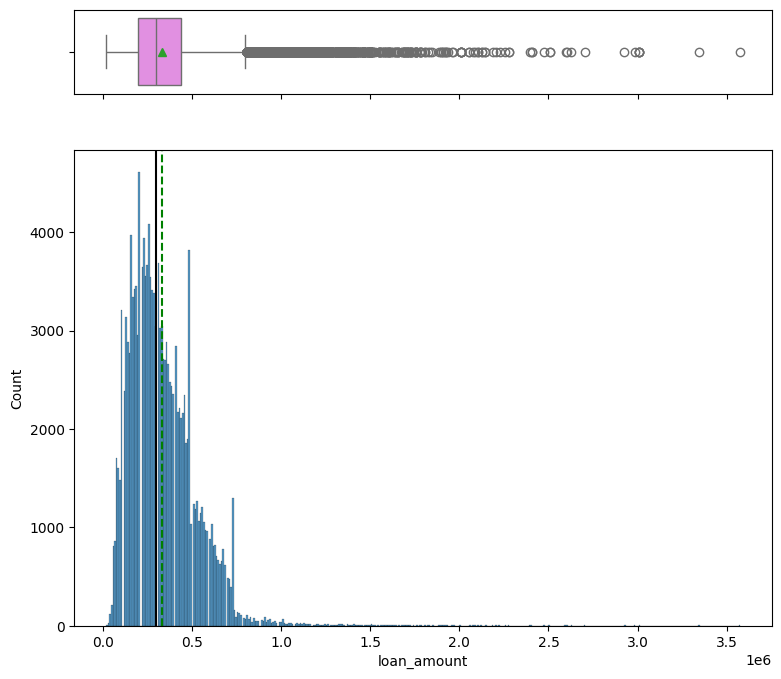

In [29]:
histogram_boxplot(df, "loan_amount")

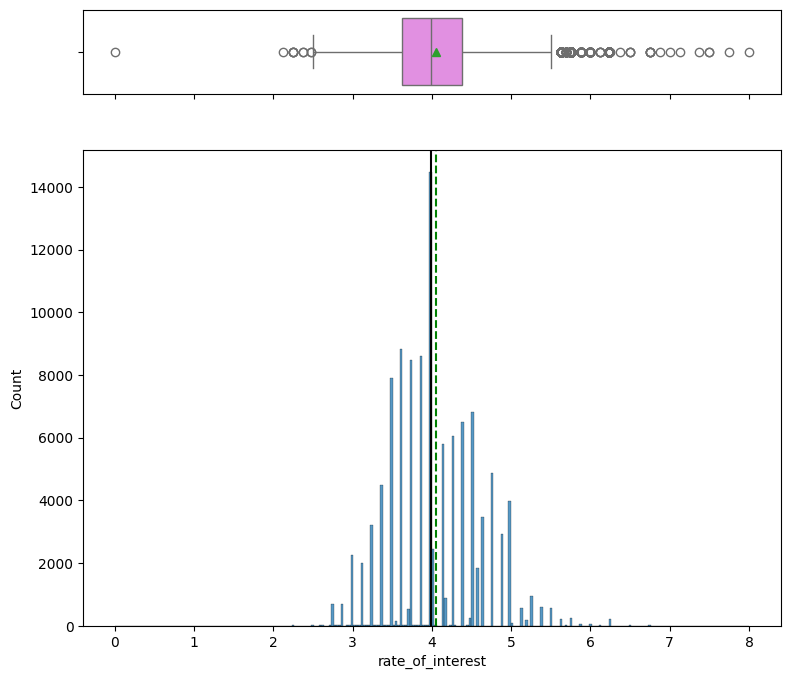

In [30]:
histogram_boxplot(df, "rate_of_interest")

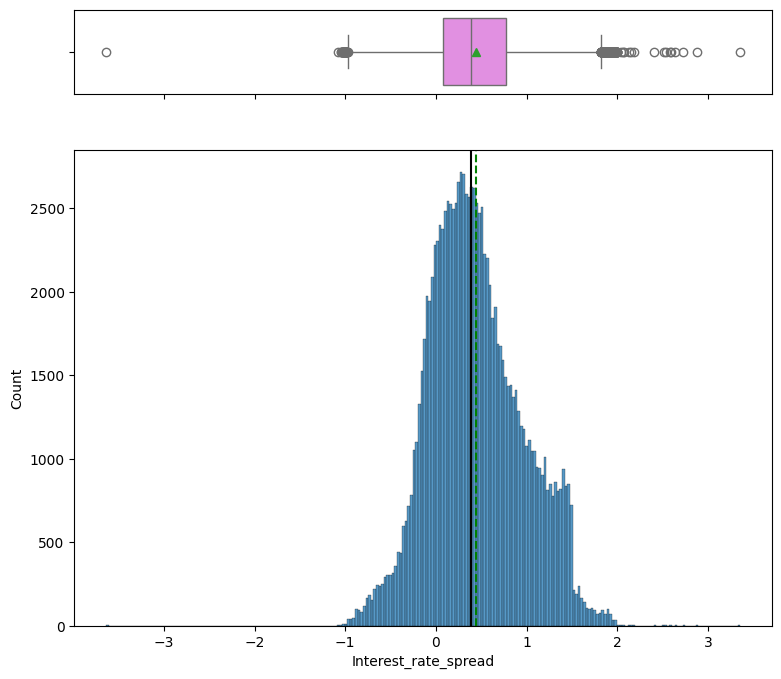

In [31]:
histogram_boxplot(df, "Interest_rate_spread")

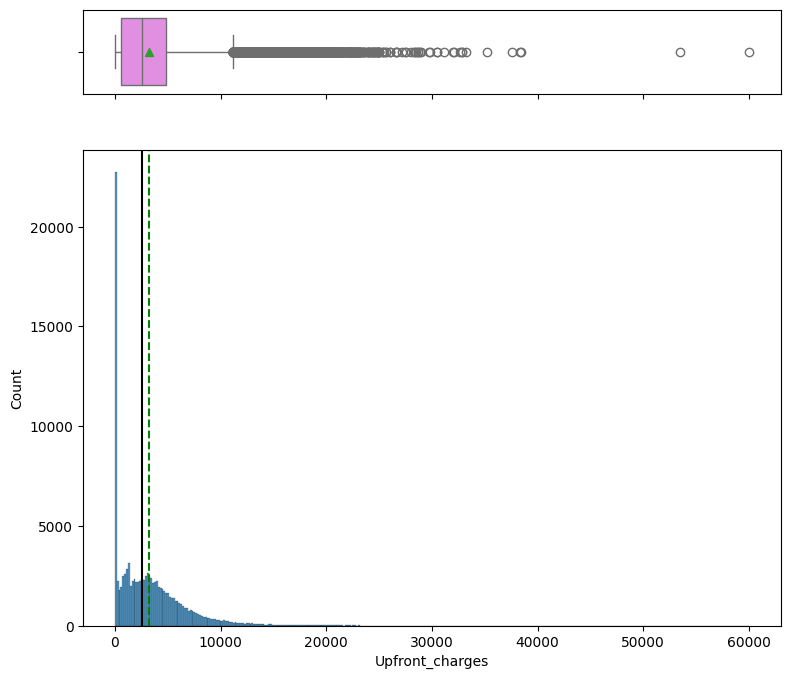

In [32]:
histogram_boxplot(df, "Upfront_charges")

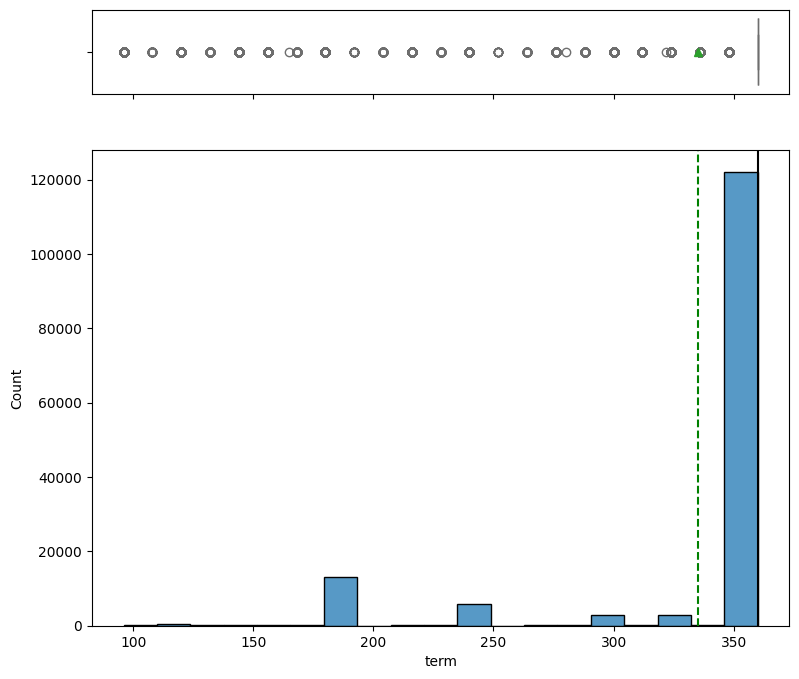

In [33]:
histogram_boxplot(df, "term")

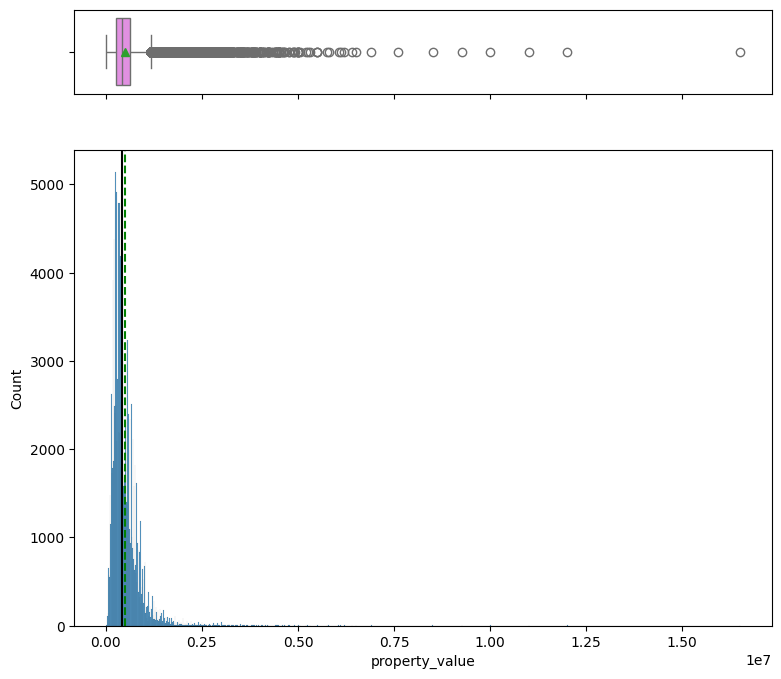

In [34]:
histogram_boxplot(df, "property_value")

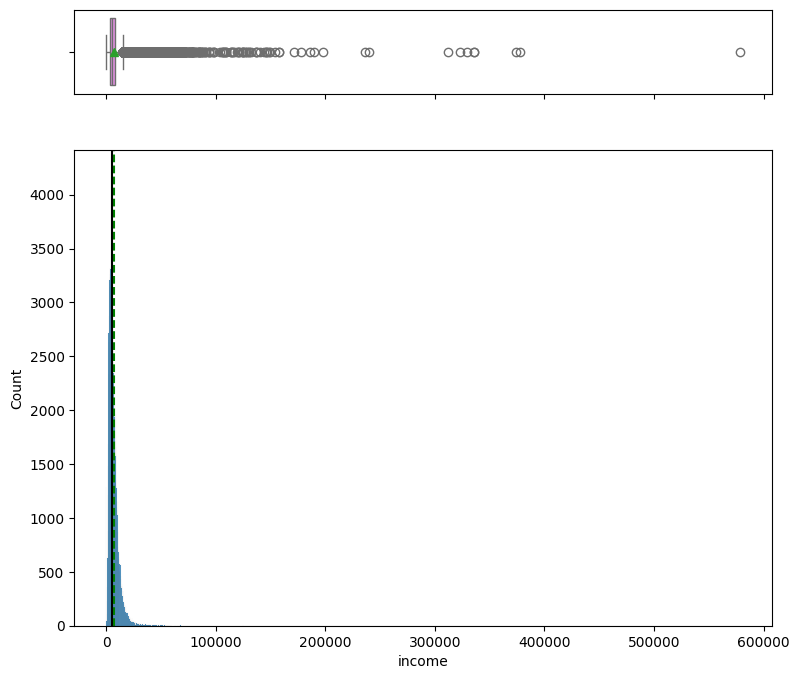

In [35]:
histogram_boxplot(df, "income")

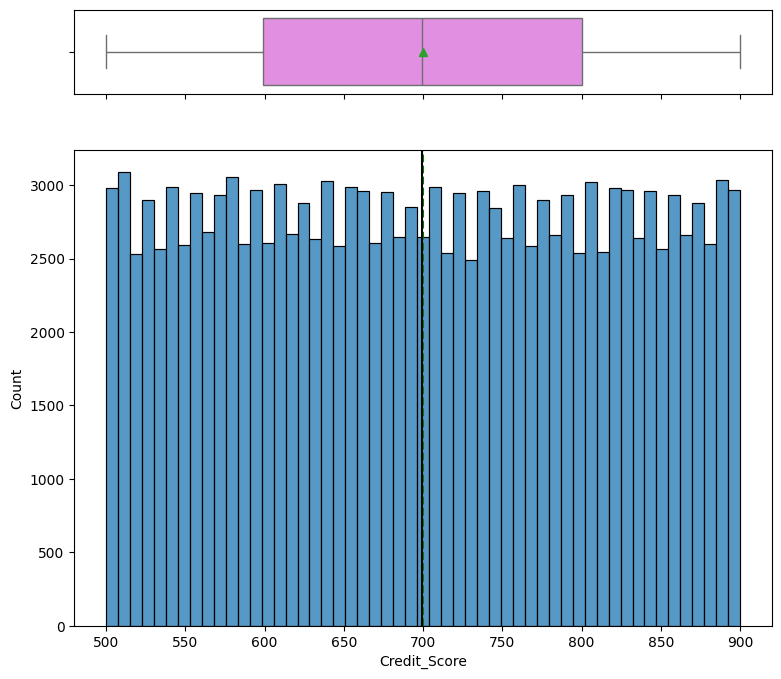

In [36]:
histogram_boxplot(df, "Credit_Score")

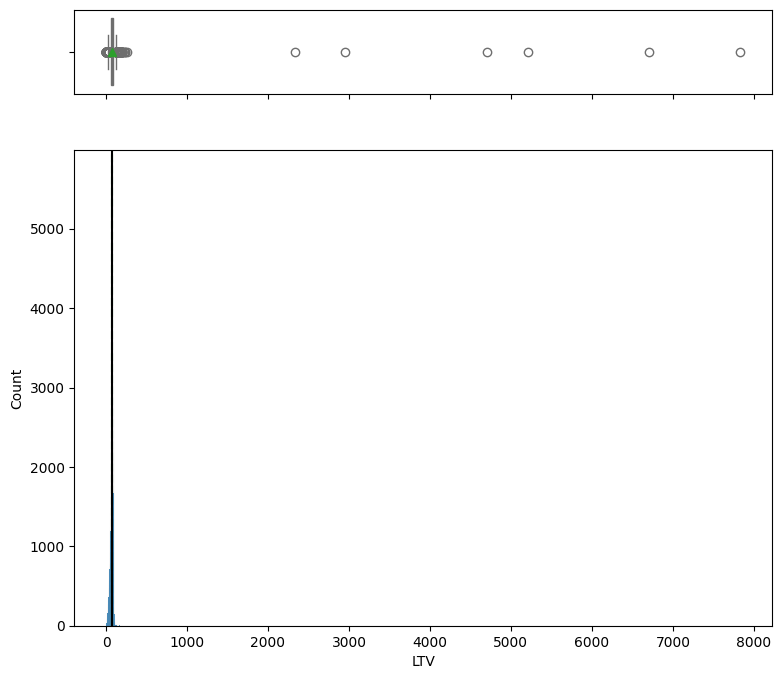

In [37]:
histogram_boxplot(df, "LTV")

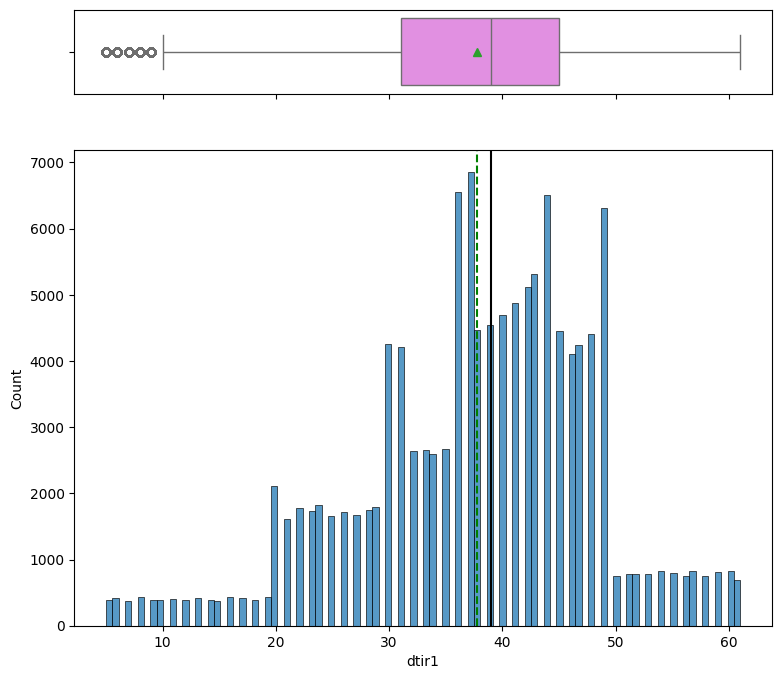

In [38]:
histogram_boxplot(df, "dtir1")

### Histogram Boxplot Observations:
-
-

In [39]:
def labelled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

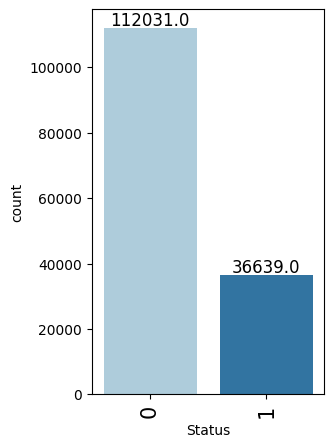

In [40]:
labelled_barplot(df, "Status")

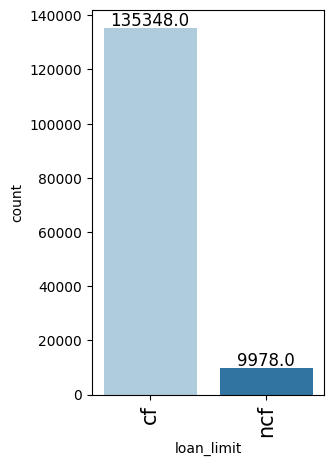

In [41]:
labelled_barplot(df, "loan_limit")

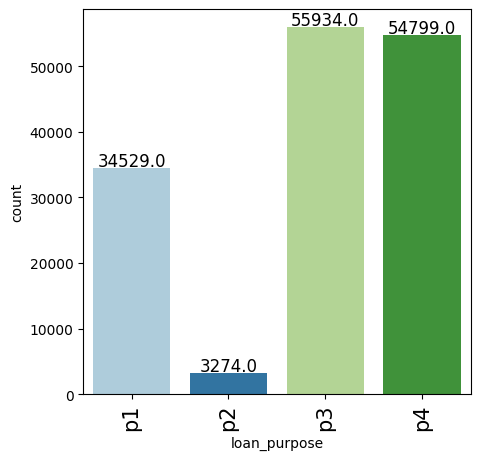

In [42]:
labelled_barplot(df, "loan_purpose")

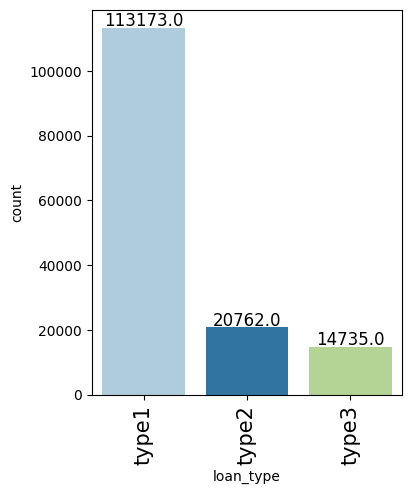

In [43]:
labelled_barplot(df, "loan_type")

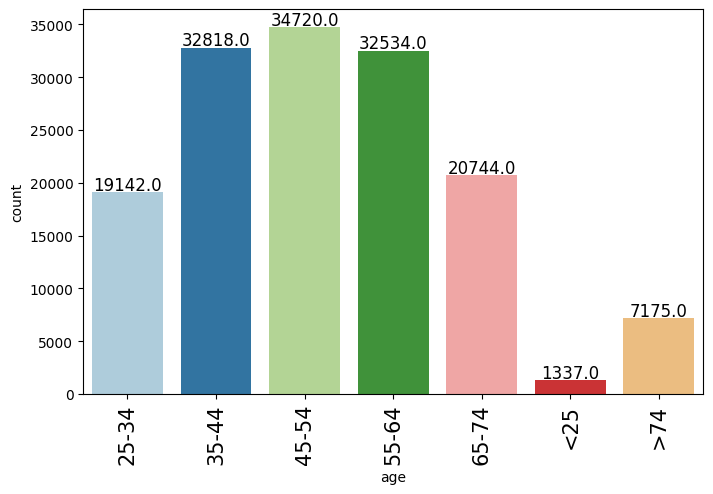

In [44]:
labelled_barplot(df, "age")

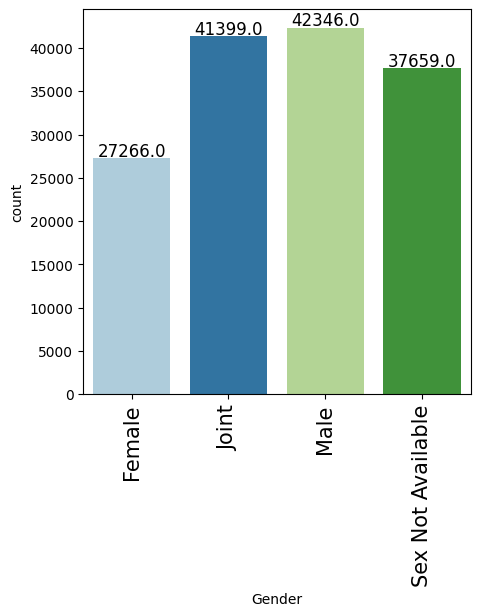

In [45]:
labelled_barplot(df, "Gender")

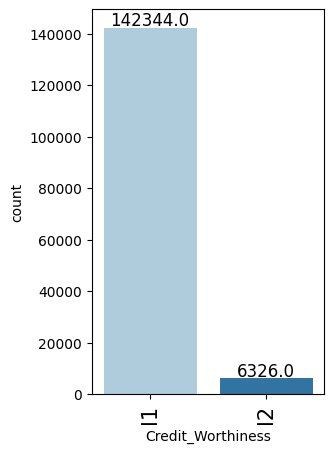

In [46]:
labelled_barplot(df, "Credit_Worthiness")

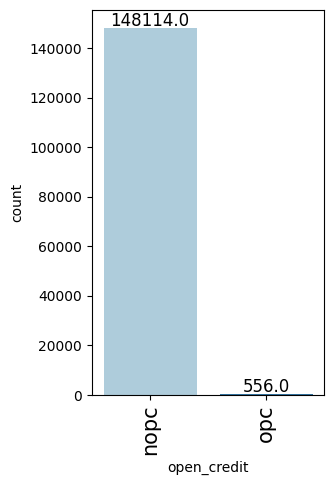

In [47]:
labelled_barplot(df, "open_credit")

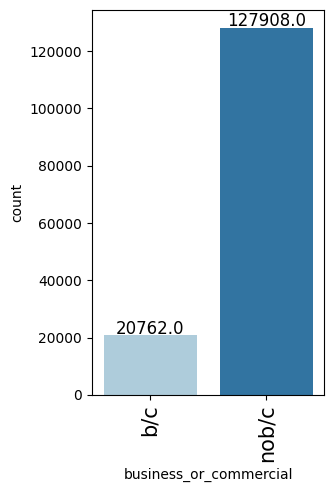

In [48]:
labelled_barplot(df, "business_or_commercial")

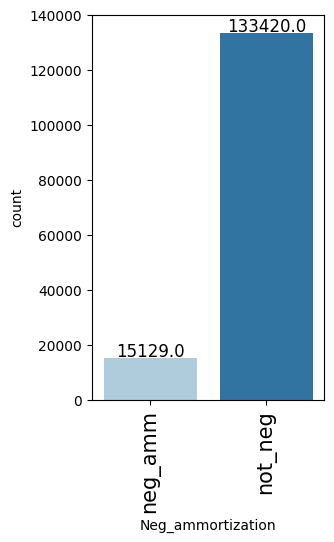

In [49]:
labelled_barplot(df, "Neg_ammortization")

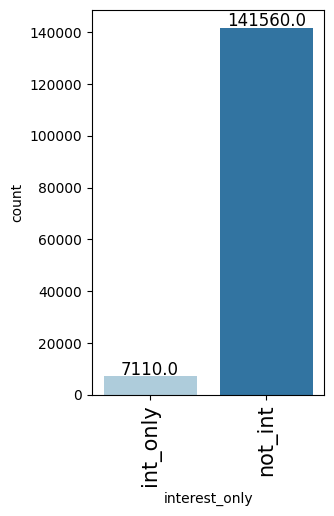

In [50]:
labelled_barplot(df, "interest_only")

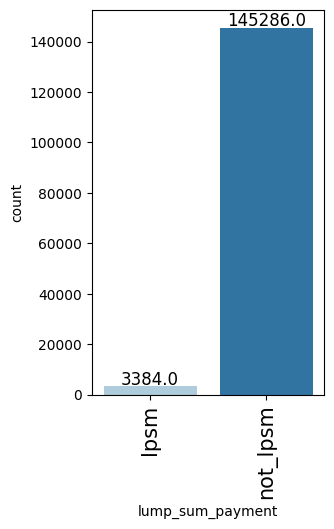

In [51]:
labelled_barplot(df, "lump_sum_payment")

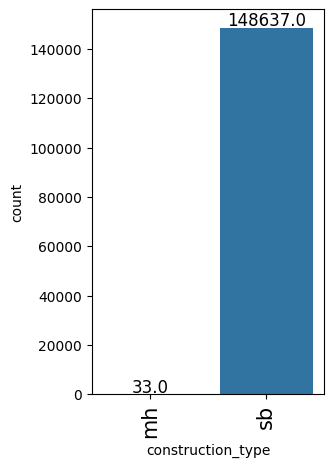

In [52]:
labelled_barplot(df, "construction_type")

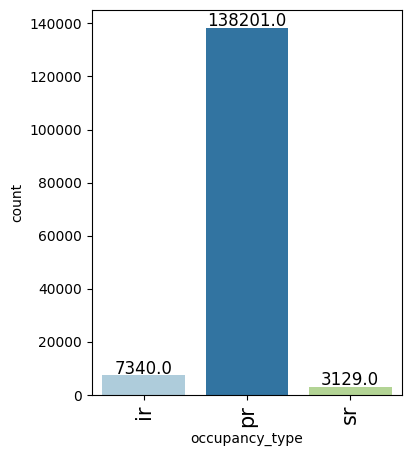

In [53]:
labelled_barplot(df, "occupancy_type")

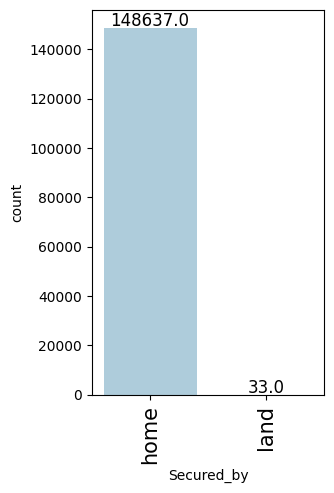

In [54]:
labelled_barplot(df, "Secured_by")

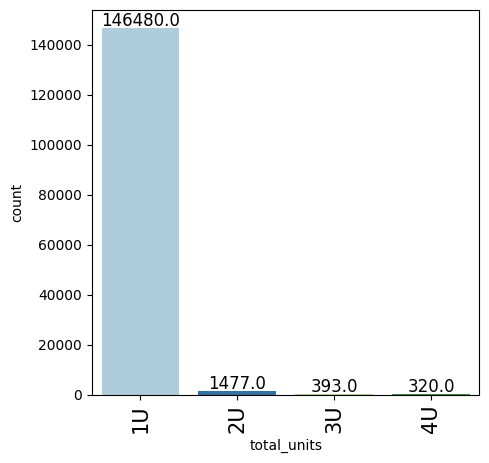

In [55]:
labelled_barplot(df, "total_units")

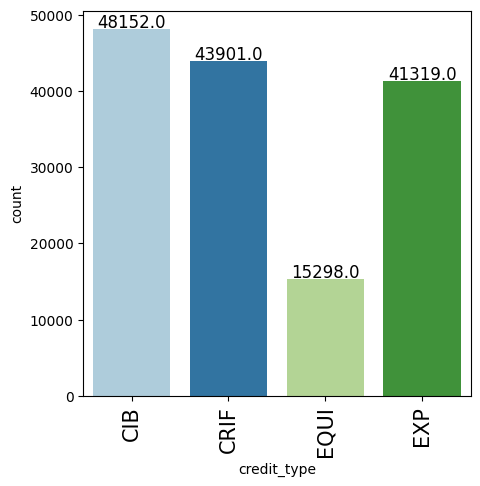

In [56]:
labelled_barplot(df, "credit_type")

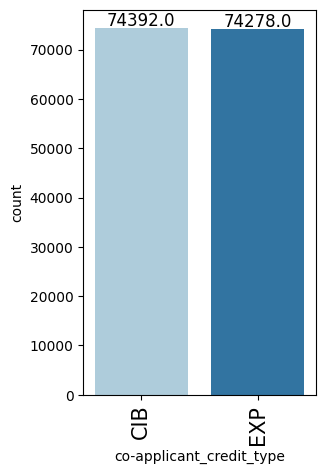

In [57]:
labelled_barplot(df, "co-applicant_credit_type")

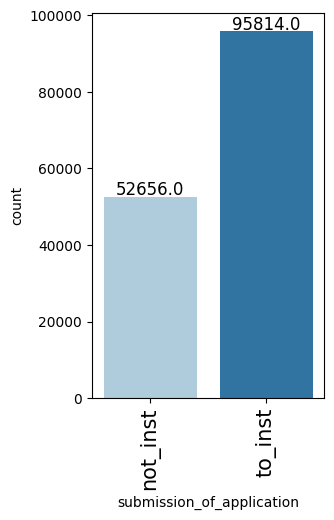

In [58]:
labelled_barplot(df, "submission_of_application")

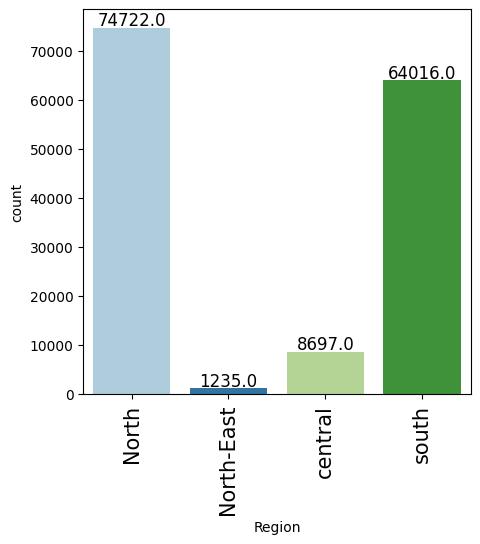

In [59]:
labelled_barplot(df, "Region")

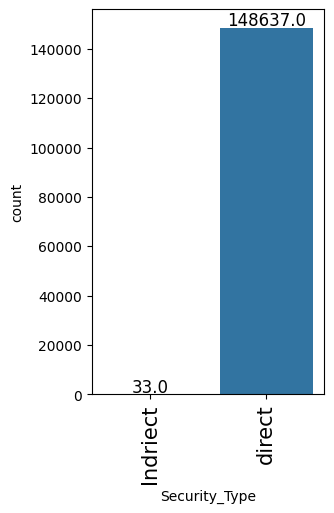

In [60]:
labelled_barplot(df, "Security_Type")

### Labelled Bar Plots Observations:
-
-


#Bivariate Analysis

<Axes: xlabel='Status', ylabel='loan_amount'>

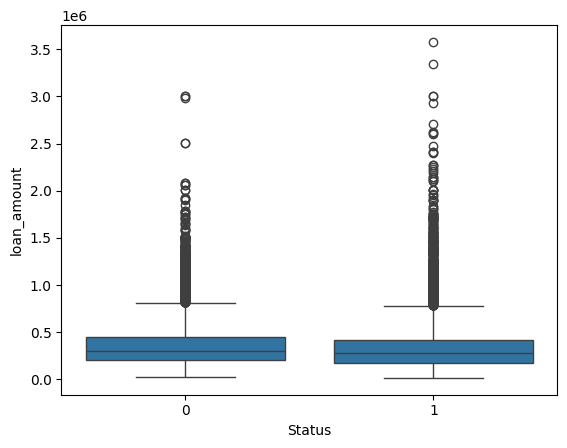

In [61]:
sns.boxplot(x="Status", y="loan_amount", data=df)

<Axes: xlabel='Status', ylabel='rate_of_interest'>

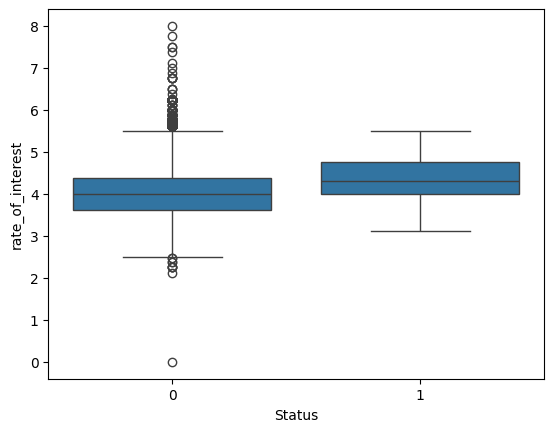

In [62]:
sns.boxplot(x="Status", y="rate_of_interest", data=df)

<Axes: xlabel='Status', ylabel='Upfront_charges'>

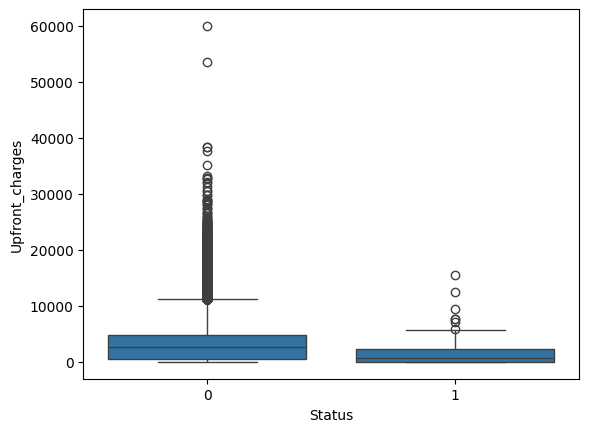

In [63]:
sns.boxplot(x="Status", y="Upfront_charges", data=df)

<Axes: xlabel='Status', ylabel='income'>

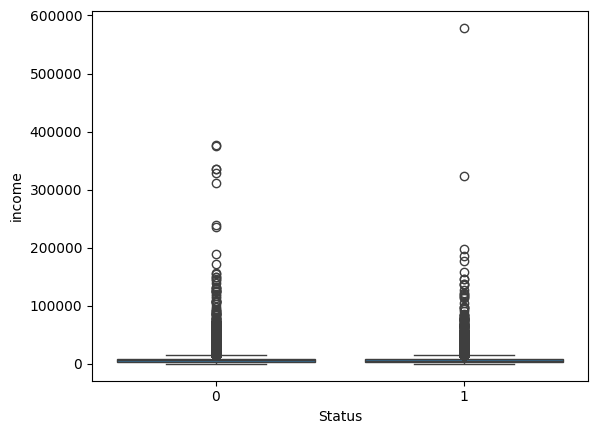

In [64]:
sns.boxplot(x="Status", y="income", data=df)

<Axes: xlabel='Status', ylabel='Credit_Score'>

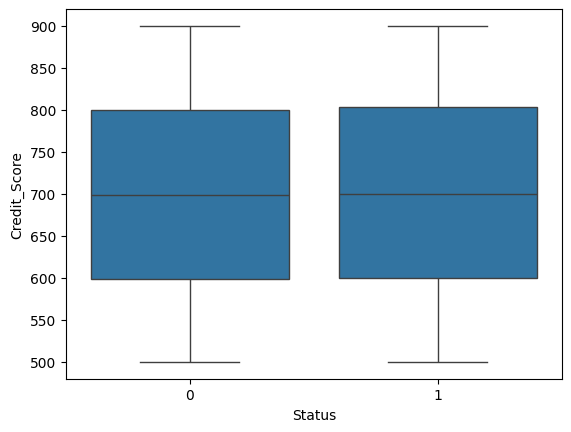

In [65]:
sns.boxplot(x="Status", y="Credit_Score", data=df)

<Axes: xlabel='Status', ylabel='LTV'>

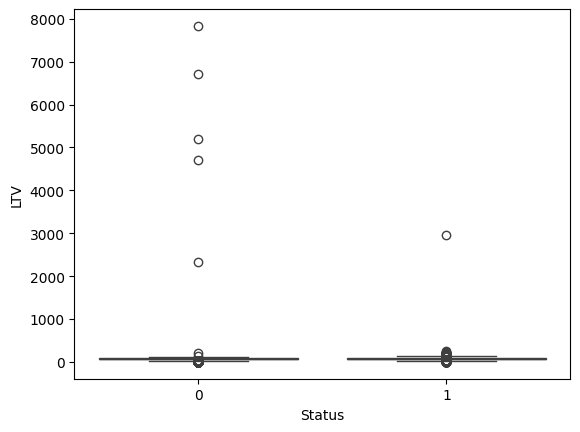

In [66]:
sns.boxplot(x="Status", y="LTV", data=df)

<Axes: xlabel='Status', ylabel='dtir1'>

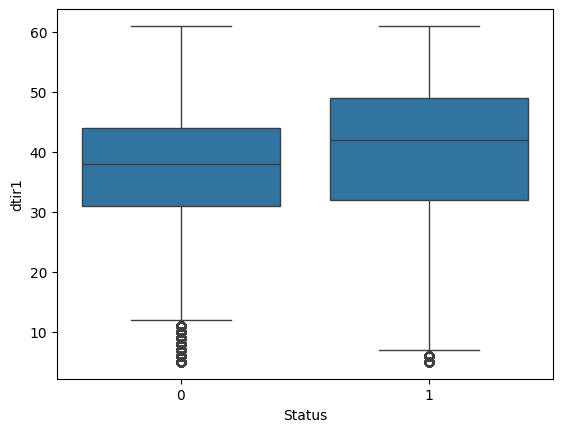

In [67]:
sns.boxplot(x="Status", y="dtir1", data=df)

<Axes: xlabel='loan_purpose', ylabel='loan_amount'>

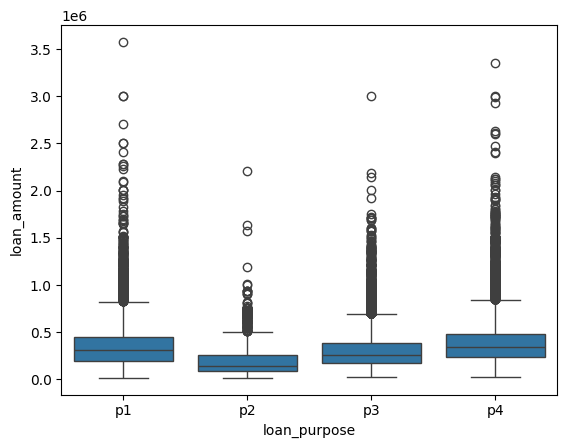

In [68]:
sns.boxplot(x="loan_purpose", y="loan_amount", data=df)

<Axes: xlabel='loan_purpose', ylabel='rate_of_interest'>

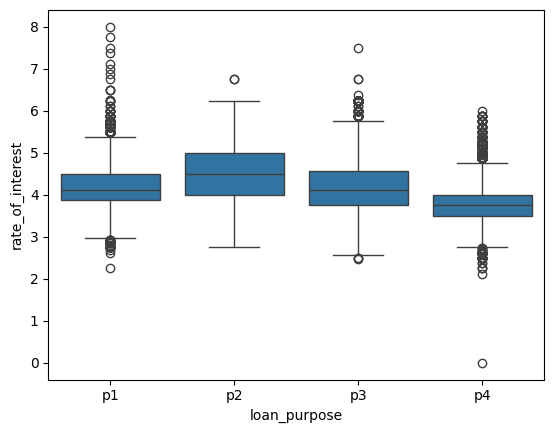

In [69]:
sns.boxplot(x="loan_purpose", y="rate_of_interest", data=df)

<Axes: xlabel='loan_purpose', ylabel='Upfront_charges'>

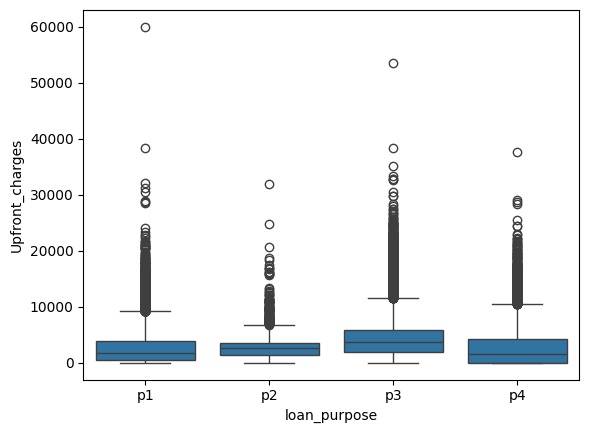

In [70]:
sns.boxplot(x="loan_purpose", y="Upfront_charges", data=df)

<Axes: xlabel='loan_amount', ylabel='rate_of_interest'>

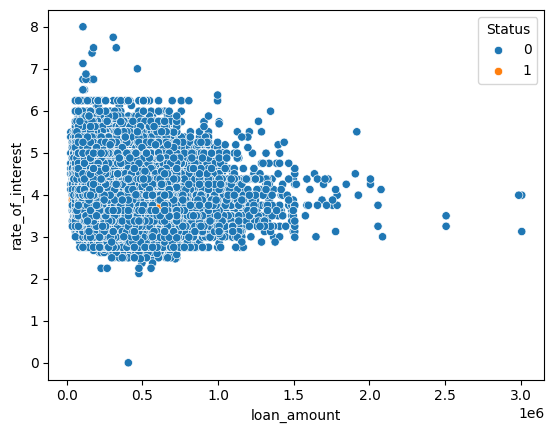

In [71]:
sns.scatterplot(x="loan_amount", y="rate_of_interest", hue="Status", data=df)

<Axes: xlabel='loan_amount', ylabel='Upfront_charges'>

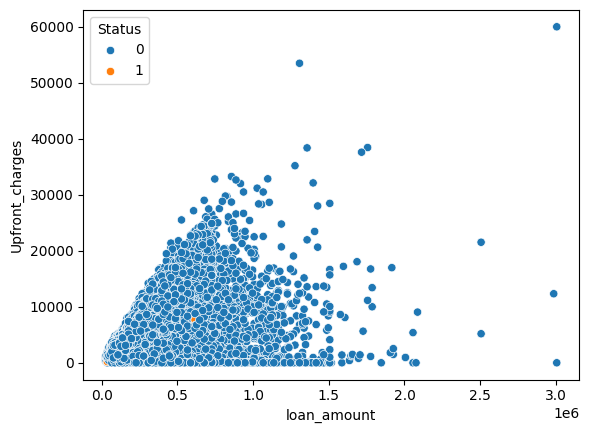

In [72]:
sns.scatterplot(x="loan_amount", y="Upfront_charges", hue="Status", data=df)

<Axes: xlabel='loan_amount', ylabel='income'>

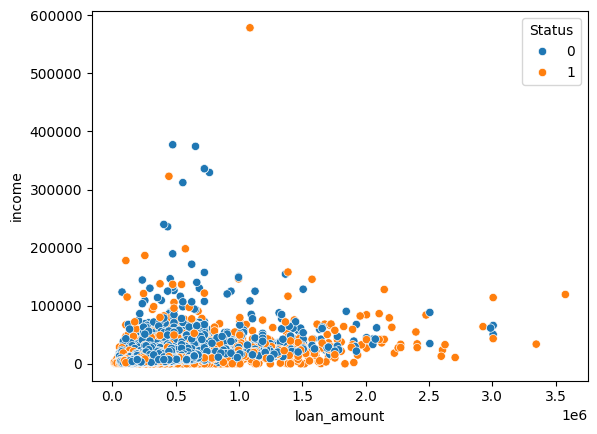

In [73]:
sns.scatterplot(x="loan_amount", y="income", hue="Status", data=df)

<Axes: xlabel='loan_amount', ylabel='Credit_Score'>

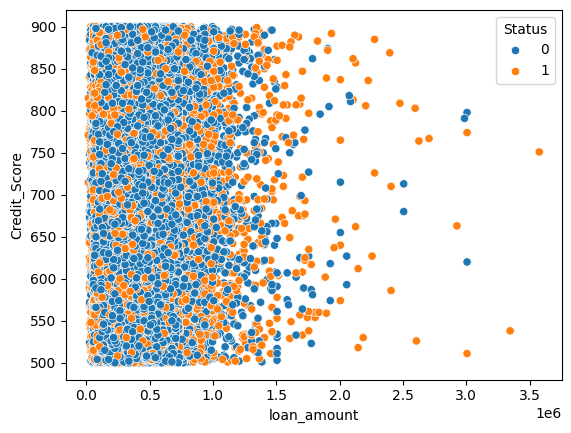

In [74]:
sns.scatterplot(x="loan_amount", y="Credit_Score", hue="Status", data=df)

<Axes: xlabel='loan_amount', ylabel='LTV'>

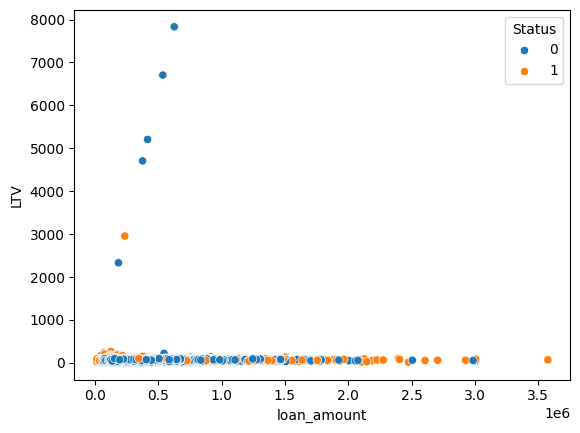

In [75]:
sns.scatterplot(x="loan_amount", y="LTV", hue="Status", data=df)

<Axes: xlabel='loan_amount', ylabel='dtir1'>

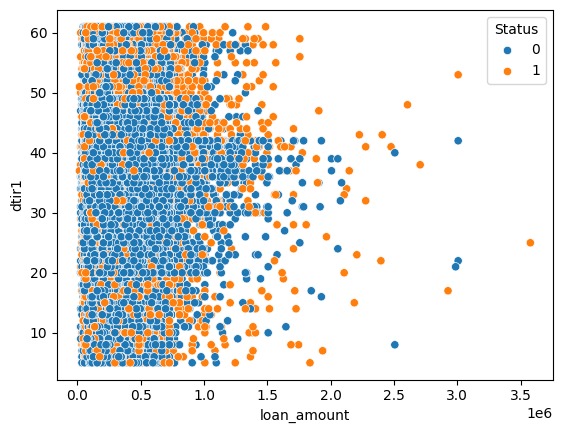

In [76]:
sns.scatterplot(x="loan_amount", y="dtir1", hue="Status", data=df)

<Axes: xlabel='Credit_Score', ylabel='dtir1'>

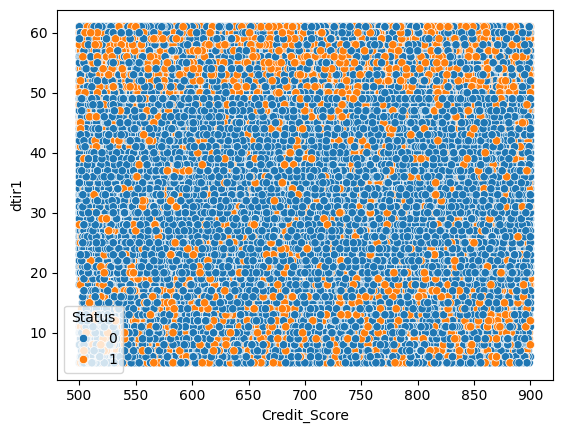

In [77]:
sns.scatterplot(x="Credit_Score", y="dtir1", hue="Status", data=df)

In [78]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Status             0      1     All
loan_purpose                       
All           111932  36604  148536
p3             41938  13996   55934
p4             42209  12590   54799
p1             25594   8935   34529
p2              2191   1083    3274
------------------------------------------------------------------------------------------------------------------------


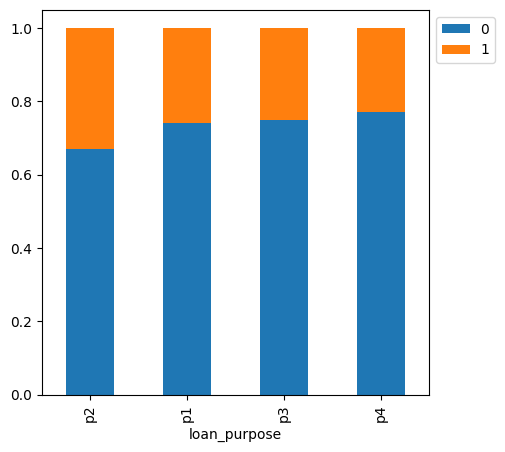

In [79]:
stacked_barplot(df, "loan_purpose", "Status")

Status          0      1     All
loan_type                       
All        112031  36639  148670
type1       87398  25775  113173
type2       13590   7172   20762
type3       11043   3692   14735
------------------------------------------------------------------------------------------------------------------------


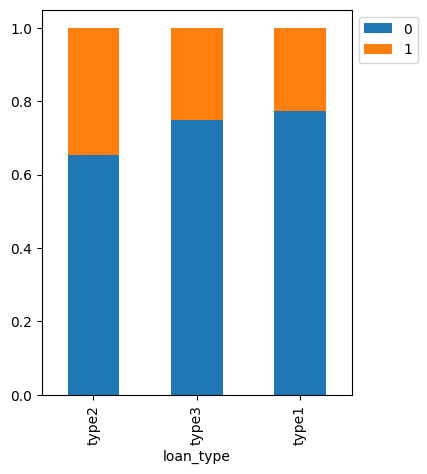

In [80]:
stacked_barplot(df, "loan_type", "Status")

Status       0      1     All
age                          
All     112031  36439  148470
55-64    24112   8422   32534
45-54    26371   8349   34720
35-44    25509   7309   32818
65-74    15173   5571   20744
25-34    14894   4248   19142
>74       5022   2153    7175
<25        950    387    1337
------------------------------------------------------------------------------------------------------------------------


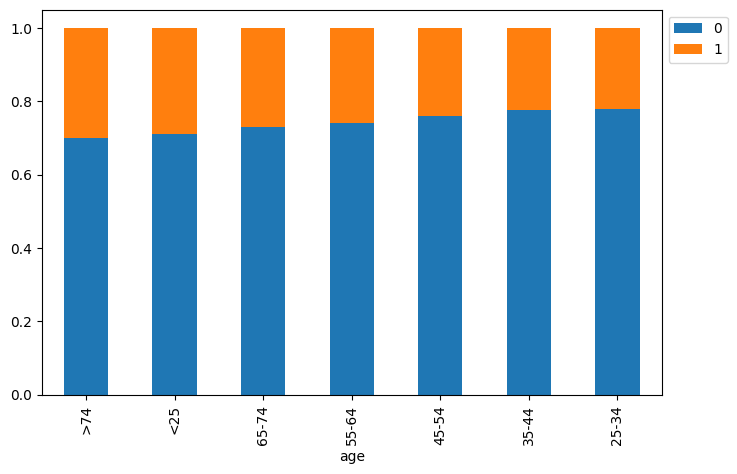

In [81]:
stacked_barplot(df, "age", "Status")

## Bivariate Analysis Observation

# Multivariate Analysis

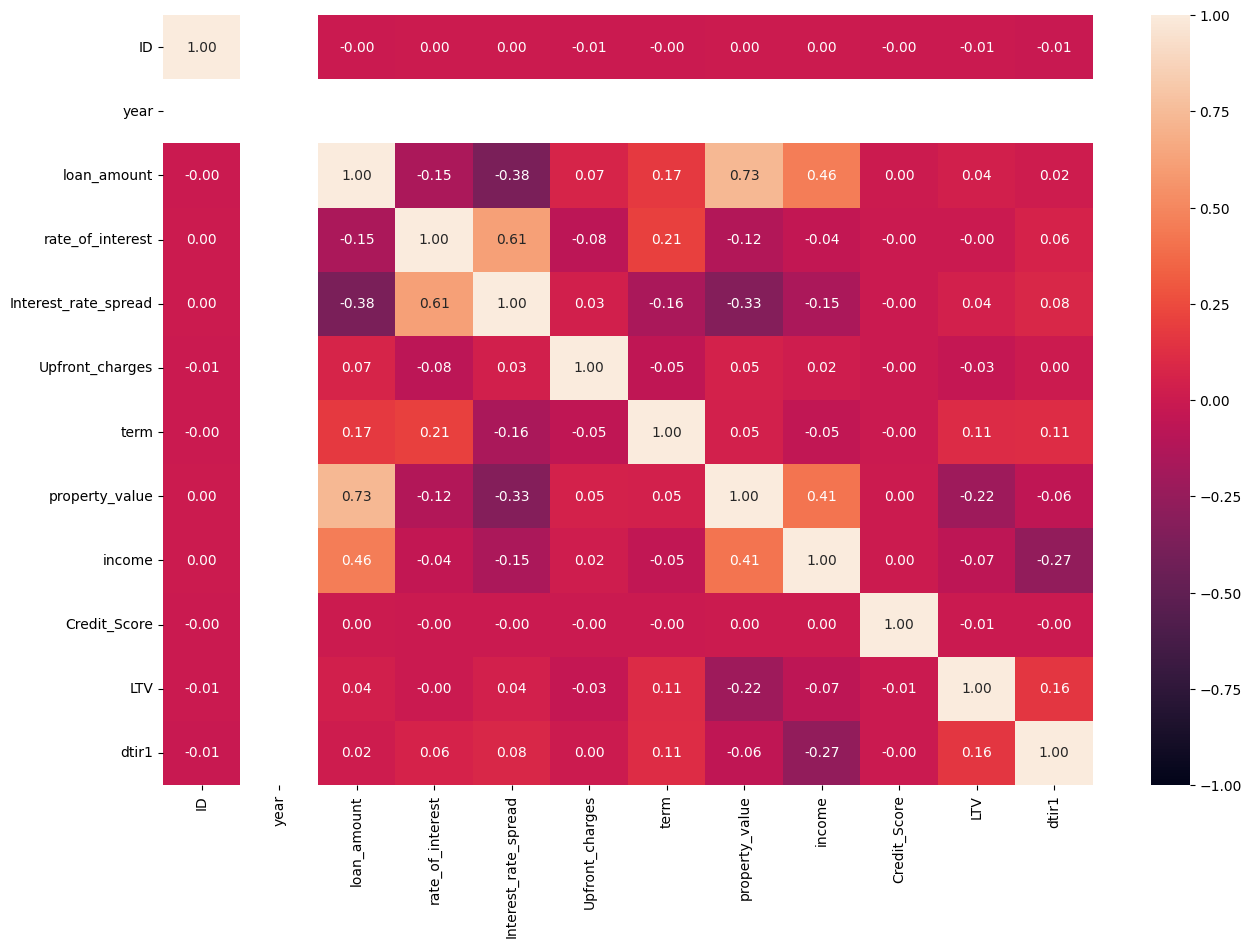

In [ ]:
plt.figure(figsize = (15, 10))
numeric_df = df.select_dtypes(include = ['number'])
sns.heatmap(numeric_df.corr(), annot = True, vmin=-1, vmax=1, fmt=".2f")
plt.show()

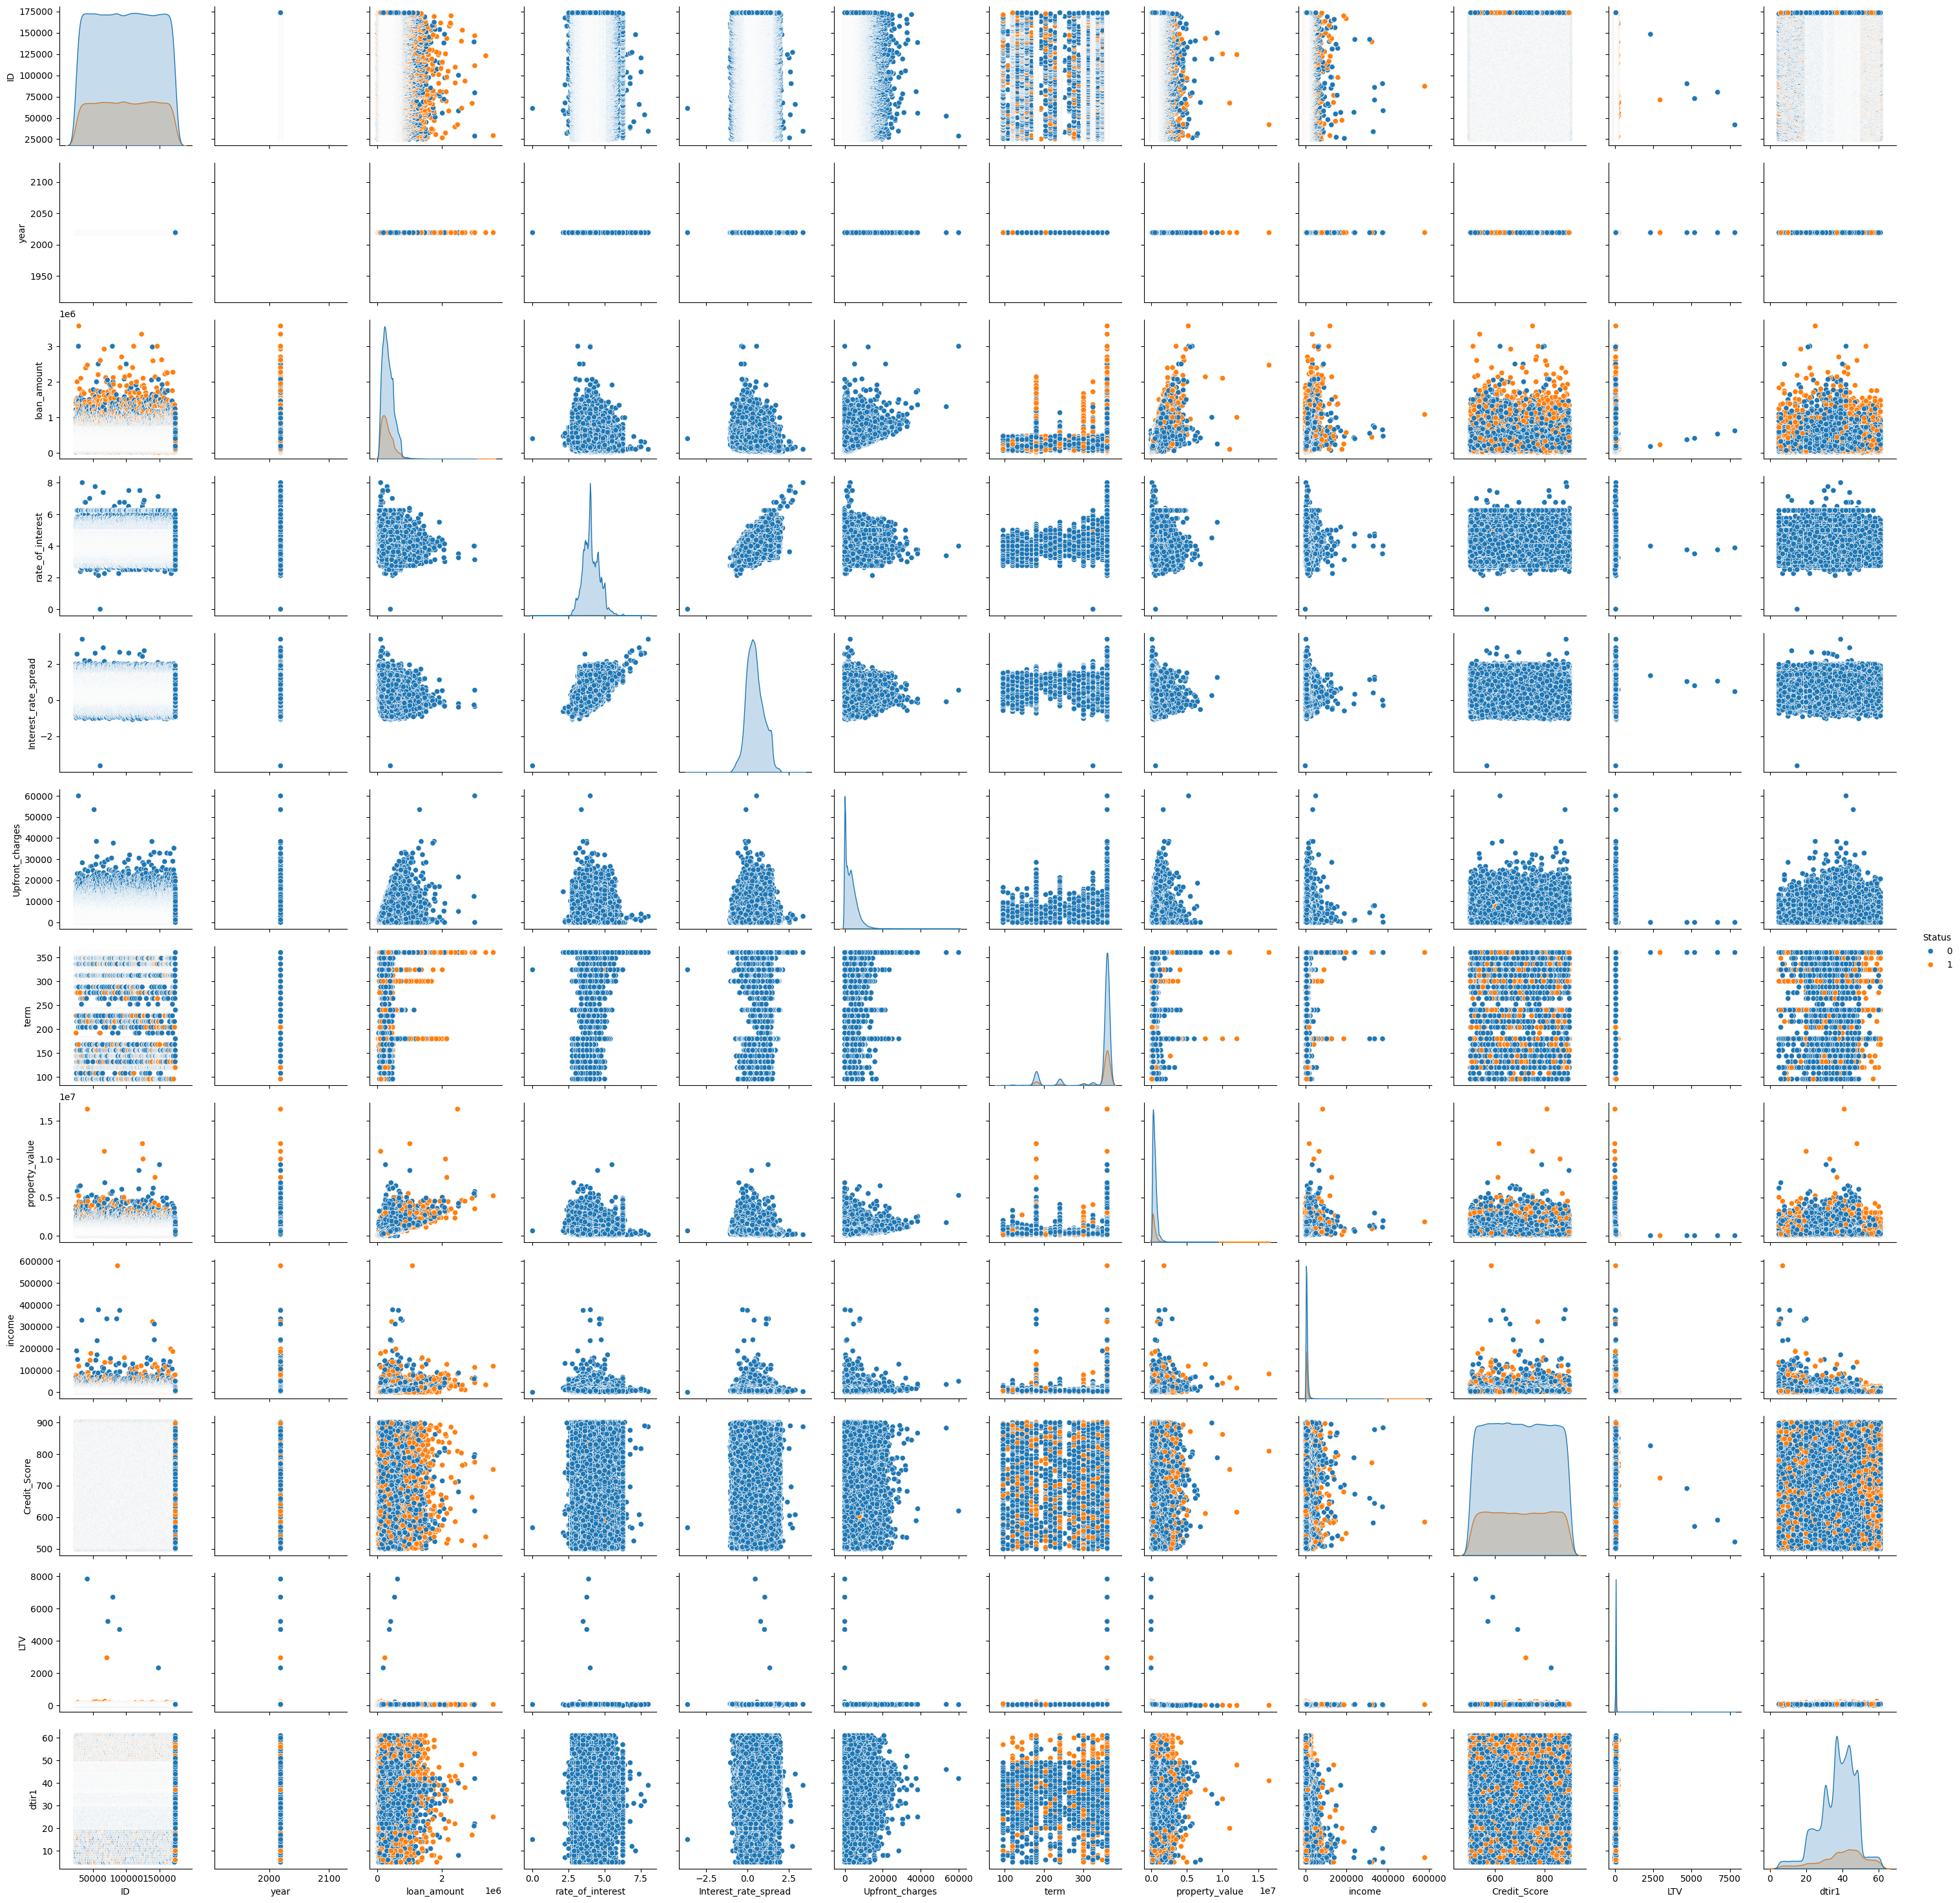

In [ ]:
sns.pairplot(df, hue="Status")

# Treating Outliers
Sometimes when the outliers are too far away from the data it could affect the training negatively, especially if the outliers are only a few points
See how it has skewed the data below?

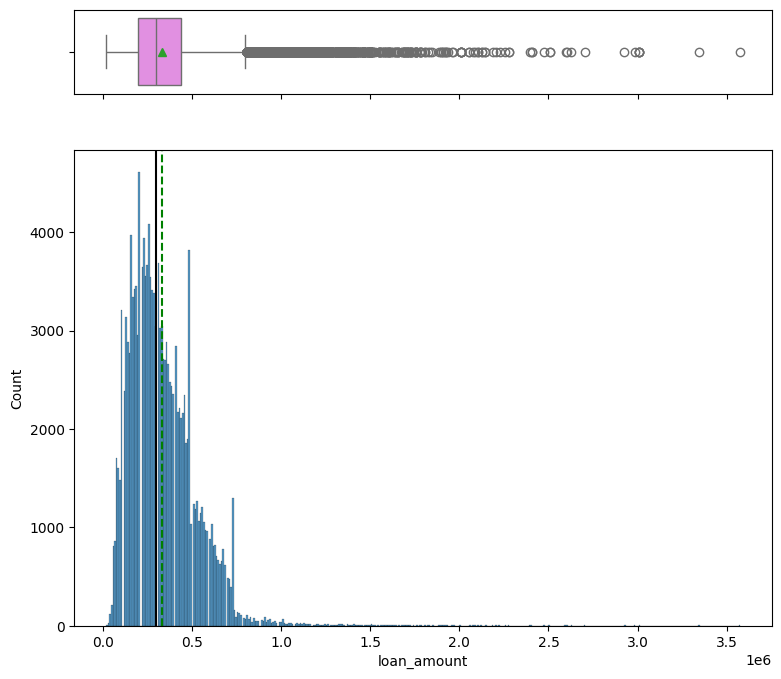

In [82]:
histogram_boxplot(df, "loan_amount")

Calculating the Quartiles to remove values beyond the whiskers

In [83]:
def find_outlier(df, col):
  Q1 = df[col].quantile(q=0.25) # Finding the first quartile

  Q3 = df[col].quantile(q=0.75) # Finding the third quartile

  IQR = Q3 - Q1 # Finding the Inter Quartile Range

  upper_whisker = (Q3 + 1.5 * IQR) # Calculating the Upper Whisker for the Income variable
  lower_whisker = (Q1 - 1.5 * IQR) # Calculating the Lower Whisker for the Income variable

  df[col] = np.clip(df[col], lower_whisker, upper_whisker) # Clipping values outside the interval

  return df



In [84]:
df_t = df.copy()

numeric_df = df_t.select_dtypes(include = ['number'])
for col in numeric_df.columns:
  df_t = find_outlier(df_t, col)

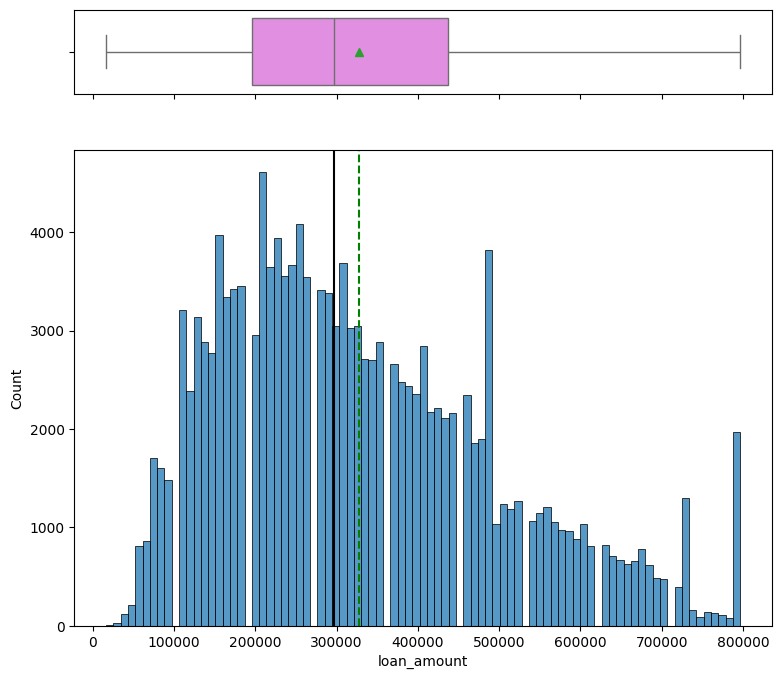

In [85]:
histogram_boxplot(df_t, "loan_amount")

In [86]:
df_t.shape

(148670, 34)

# Treating the Missing Values
We saw at the very beginning that there were quite a few missing values
We can fix that by assuming that the missing numbers would have a value of whatever is the mean value of that feature, and the categorical values would have whatever the most frequent, or mode, is of that feature.

That being said, with some columns, the percentage of the missing values is too high, so using these methods for them might not give accurate results.

Therefore, we will be dropping columns with a higher than 10% missing values.

In [87]:
percent_missing_ = df_t.isnull().sum() * 100 / len(df)
missing_value_df_t = pd.DataFrame({'percent_missing': percent_missing_})
missing_value_df_t

,percent_missing
ID,0.000000
year,0.000000
loan_limit,2.249277
Gender,0.000000
approv_in_adv,0.610749
loan_type,0.000000
loan_purpose,0.090133
Credit_Worthiness,0.000000
open_credit,0.000000
business_or_commercial,0.000000


In [88]:
# Creating a copy of the data frame with the outliers gone to start working on missing values
df1 = df_t.copy()

In [89]:
# Adding the columns of >10% missing values to be dropped in a list + the term + year + ID
columns_d = ["rate_of_interest", "Interest_rate_spread", "Upfront_charges", "property_value", "LTV", "dtir1", "term", "year", "ID"]


In [90]:
# Dropping the columns_d from the data

df1.drop(columns_d, axis = 1, inplace = True)

In [91]:
percent_missing_ = df1.isnull().sum() * 100 / len(df)
missing_value_df_t = pd.DataFrame({'percent_missing': percent_missing_})
missing_value_df_t

,percent_missing
loan_limit,2.249277
Gender,0.000000
approv_in_adv,0.610749
loan_type,0.000000
loan_purpose,0.090133
Credit_Worthiness,0.000000
open_credit,0.000000
business_or_commercial,0.000000
loan_amount,0.000000
Neg_ammortization,0.081388


In [92]:
num_data = df1.select_dtypes(include = ['number'])

cat_data = df1.select_dtypes(include = ['category'])

df1[num_data.columns] = num_data.fillna(num_data.mean())
df1[cat_data.columns] = cat_data.fillna(cat_data.mode().iloc[0])

In [93]:
percent_missing1 = df1.isnull().sum() * 100 / len(df)
missing_value_df1 = pd.DataFrame({'percent_missing': percent_missing1})
missing_value_df1

,percent_missing
loan_limit,0.0
Gender,0.0
approv_in_adv,0.0
loan_type,0.0
loan_purpose,0.0
Credit_Worthiness,0.0
open_credit,0.0
business_or_commercial,0.0
loan_amount,0.0
Neg_ammortization,0.0


In [94]:
# trying a heatmap for all data
# plt.figure(figsize = (15, 10))
# sns.heatmap(df.corr(), annot = True, vmin=-1, vmax=1, fmt=".2f")
# plt.show()

#WHATS NEXT [WIP]

We will be dropping the status axis, becasue that is what we are trying to find.

We will splot the data into x and y train and test data
- WE WILL HAVE TO LOOK AT WHAT ARE THE TEST SPLIT OPTIONS

Once we have the split we can easily train any model.

The next hardest part will be hyperparameter tuning a decision tree model

Encoding the data

In [95]:
# Scaling the data features using robust scaler


le = LabelEncoder()


cat_data = df1.select_dtypes(include = ['category'])
df1[cat_data.columns] = cat_data.apply(le.fit_transform)



In [96]:
dummies = pd.get_dummies(df1, columns=["Region"], drop_first = True)
print(dummies.dtypes)

loan_limit                     int64
Gender                         int64
approv_in_adv                  int64
loan_type                      int64
loan_purpose                   int64
Credit_Worthiness              int64
open_credit                    int64
business_or_commercial         int64
loan_amount                    int64
Neg_ammortization              int64
interest_only                  int64
lump_sum_payment               int64
construction_type              int64
occupancy_type                 int64
Secured_by                     int64
total_units                    int64
income                       float64
credit_type                    int64
Credit_Score                   int64
co-applicant_credit_type       int64
age                            int64
submission_of_application      int64
Security_Type                  int64
Status                         int64
Region_1                        bool
Region_2                        bool
Region_3                        bool
d

In [ ]:
corre = dummies.corr()

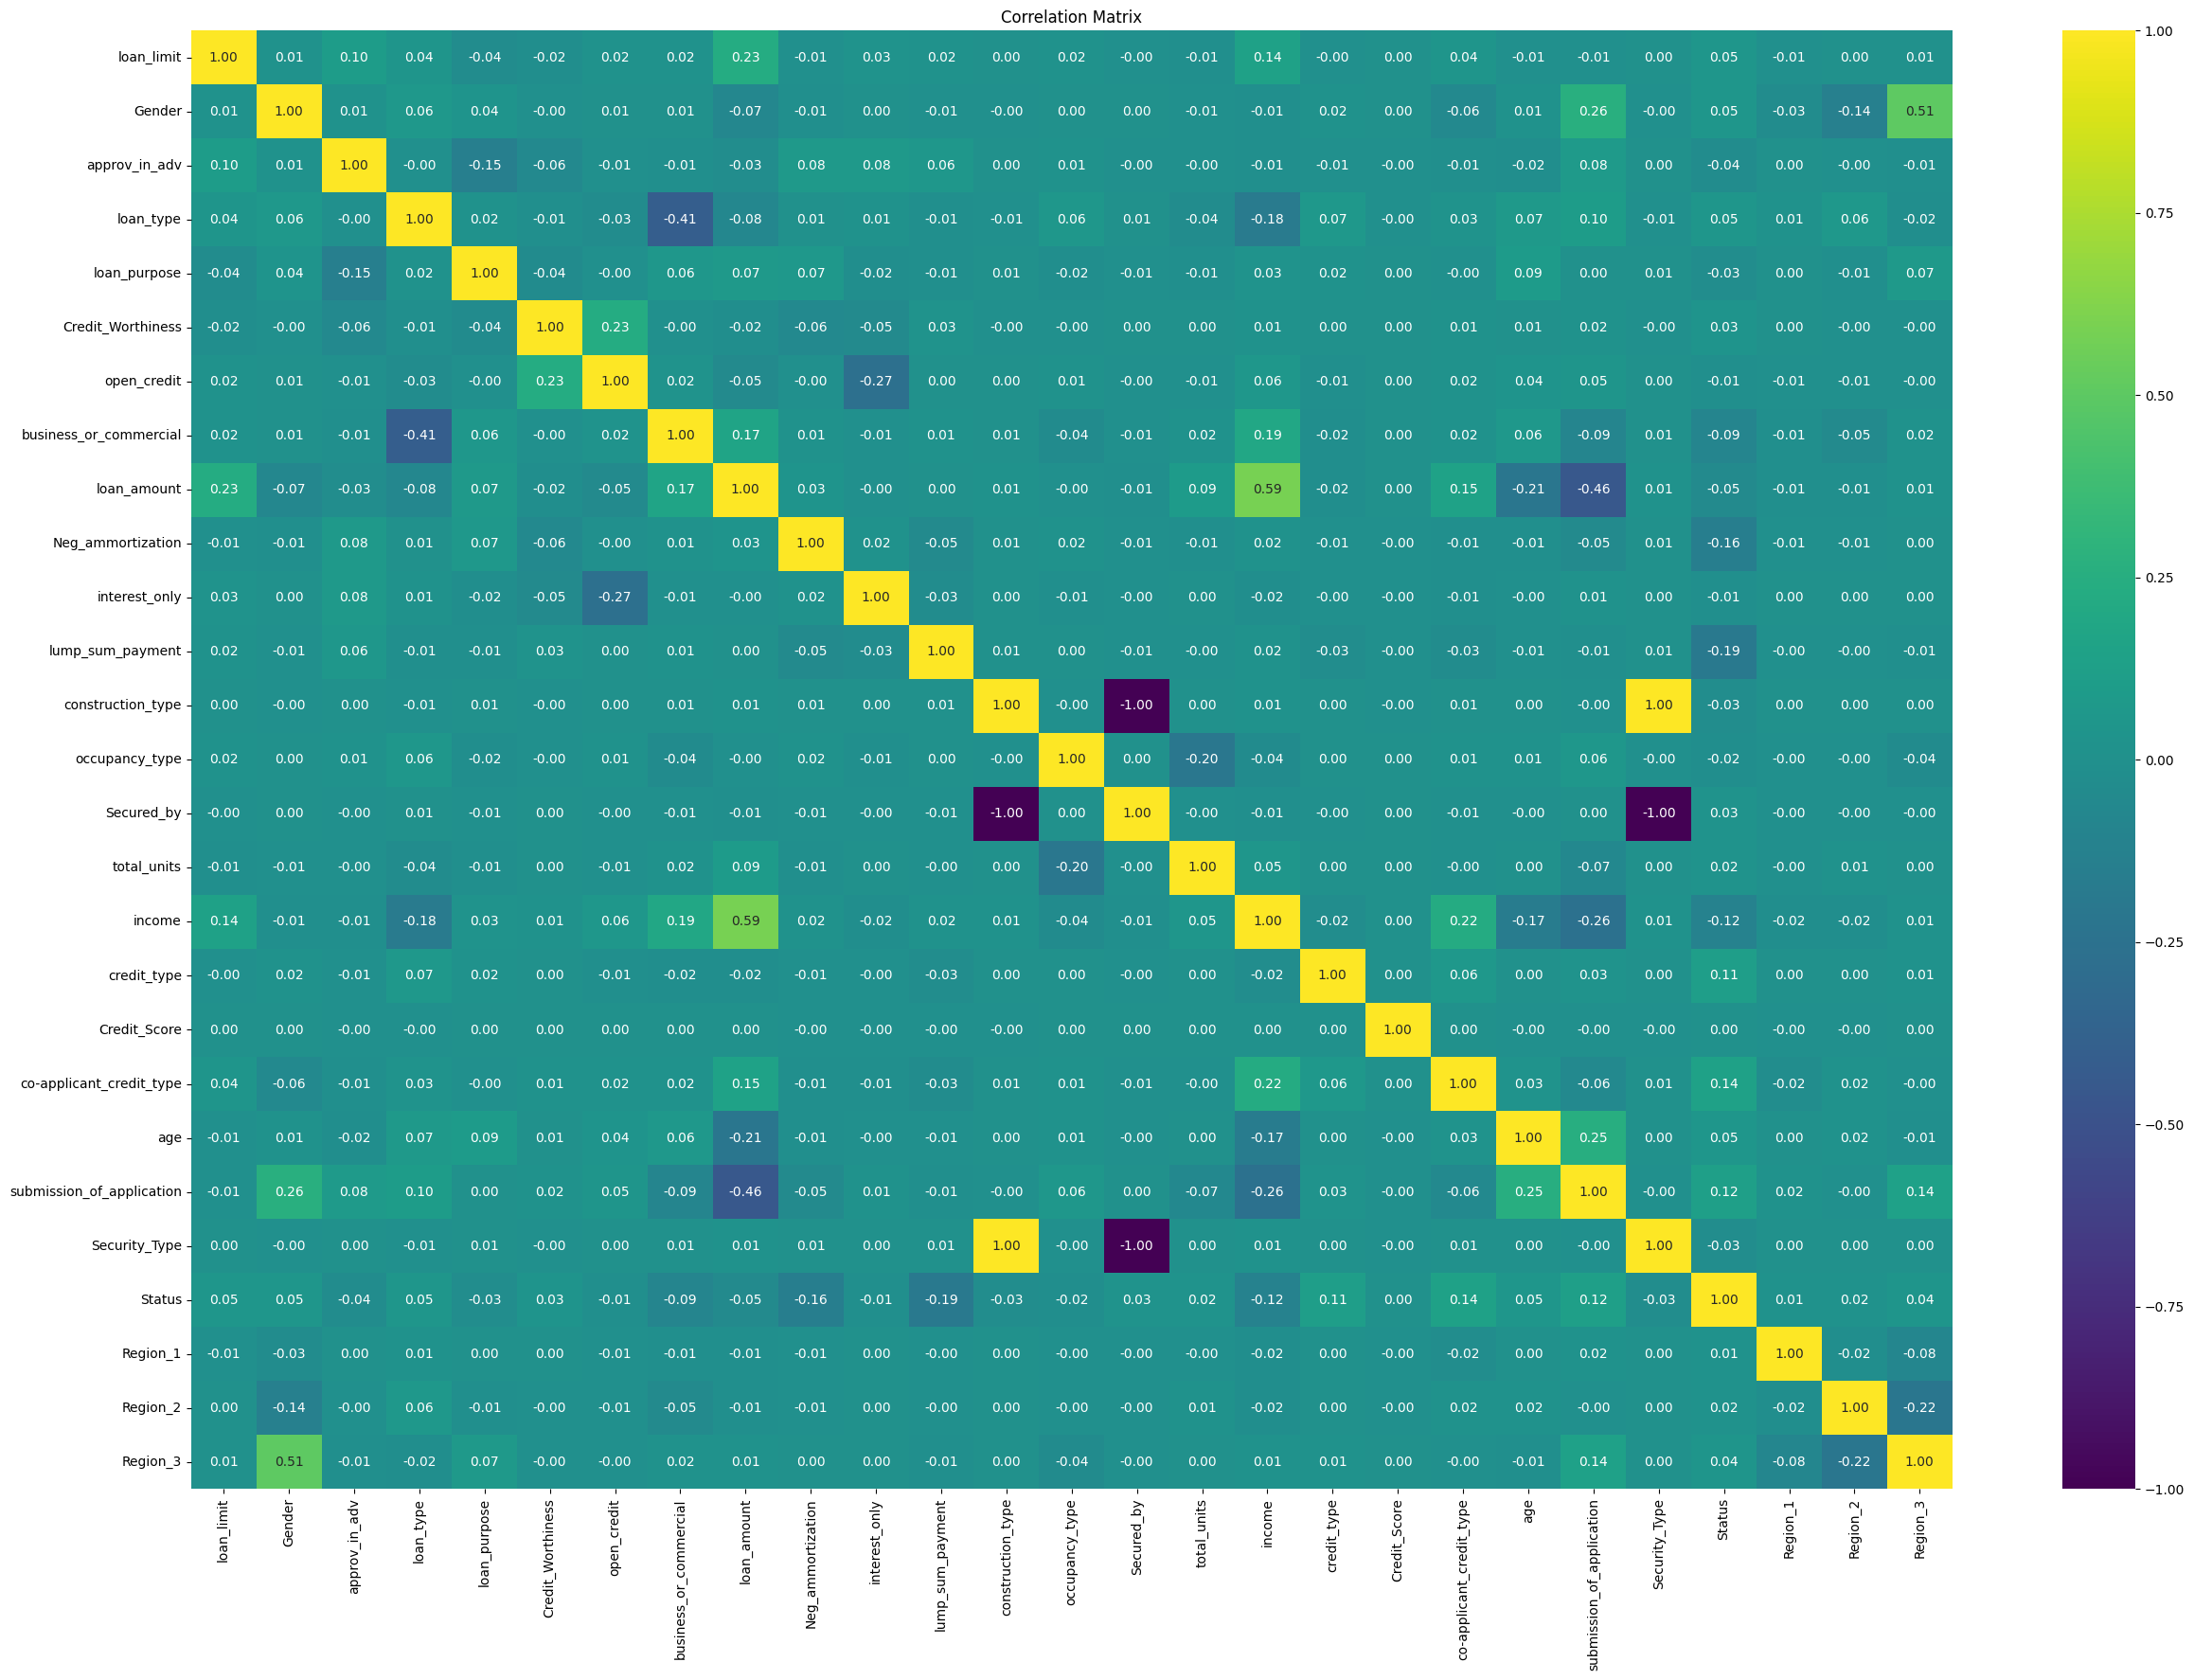

In [ ]:
plt.figure(figsize = (30, 20))
sns.heatmap(corre, annot = True, cmap="viridis", fmt=".2f", cbar=True)
plt.title("Correlation Matrix")
plt.show()

# Setting the test train split

Scaling the Numeric data

In [97]:
scaler = RobustScaler()
num_data = dummies.select_dtypes(include = ['number'])
dummies[num_data.columns] = scaler.fit_transform(num_data)

In [98]:
X = dummies.drop("Status", axis = 1)

y = dummies["Status"]


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)


In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))

(111502, 26)
(37168, 26)
(111502,)
(37168,)
Status
0.0    0.753395
1.0    0.246605
Name: proportion, dtype: float64
Status
0.0    0.754036
1.0    0.245964
Name: proportion, dtype: float64


In [101]:
#Checking the training data
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 111502 entries, 91251 to 128037
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 111502 non-null  float64
 1   Gender                     111502 non-null  float64
 2   approv_in_adv              111502 non-null  float64
 3   loan_type                  111502 non-null  float64
 4   loan_purpose               111502 non-null  float64
 5   Credit_Worthiness          111502 non-null  float64
 6   open_credit                111502 non-null  float64
 7   business_or_commercial     111502 non-null  float64
 8   loan_amount                111502 non-null  float64
 9   Neg_ammortization          111502 non-null  float64
 10  interest_only              111502 non-null  float64
 11  lump_sum_payment           111502 non-null  float64
 12  construction_type          111502 non-null  float64
 13  occupancy_type             111

#Model Building

## Metrics Score Function

In [102]:
def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['Not Defaulted', 'Defaulted'], yticklabels = ['Not Defaulted', 'Defaulted'])
    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

# Logistic Regression

In [ ]:
logr = LogisticRegression(random_state = 1)
logr.fit(X_train, y_train)

LogisticRegression(random_state=1)

              precision    recall  f1-score   support

         0.0       0.79      0.97      0.87     84005
         1.0       0.67      0.21      0.32     27497

    accuracy                           0.78    111502
   macro avg       0.73      0.59      0.59    111502
weighted avg       0.76      0.78      0.73    111502



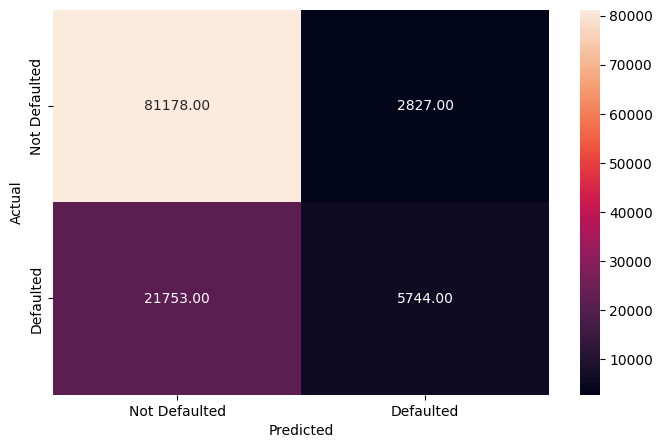

In [ ]:
pred_train_logr = logr.predict(X_train)
metrics_score(y_train, pred_train_logr)

              precision    recall  f1-score   support

         0.0       0.79      0.97      0.87     28026
         1.0       0.68      0.20      0.31      9142

    accuracy                           0.78     37168
   macro avg       0.73      0.59      0.59     37168
weighted avg       0.76      0.78      0.73     37168



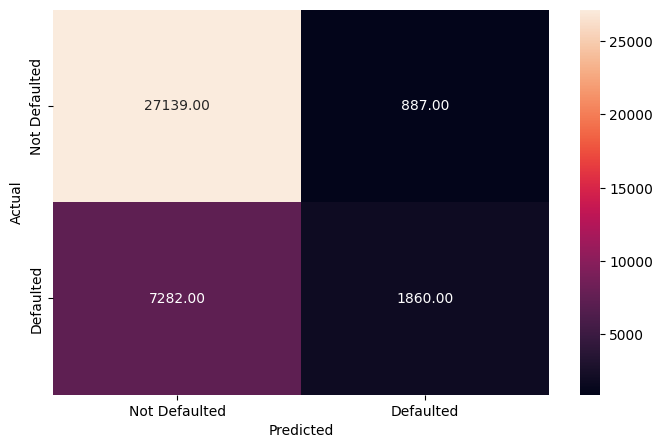

In [ ]:
pred_test_logr = logr.predict(X_test)
metrics_score(y_test, pred_test_logr)

#Decision Tree

In [ ]:
# Building a full depth decision tree
dtree = DecisionTreeClassifier(random_state = 1, class_weight = {0: 0.17, 1: 0.83})
dtree.fit(X_train, y_train)


DecisionTreeClassifier(class_weight={0: 0.17, 1: 0.83}, random_state=1)

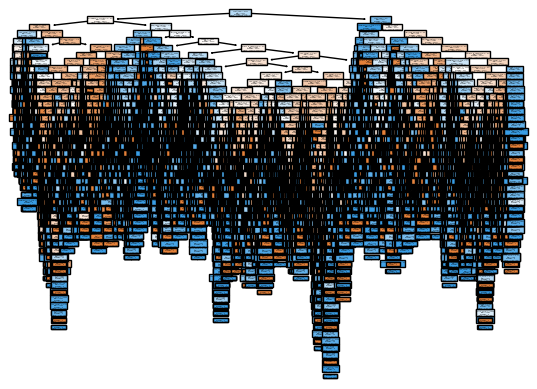

In [ ]:
tree.plot_tree(dtree, feature_names = X_train.columns, filled = True)
plt.show()

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     84005
         1.0       1.00      1.00      1.00     27497

    accuracy                           1.00    111502
   macro avg       1.00      1.00      1.00    111502
weighted avg       1.00      1.00      1.00    111502



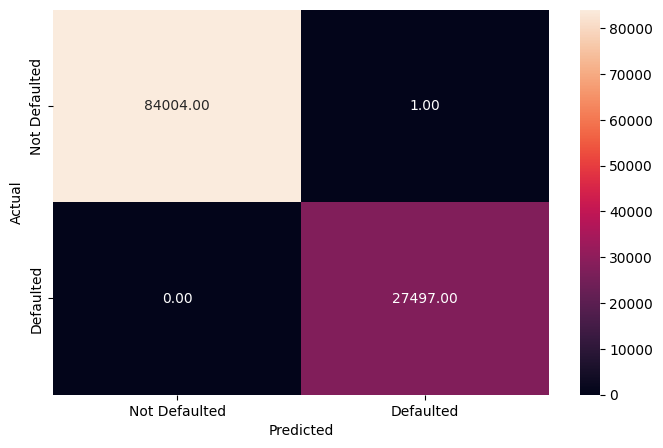

In [ ]:
pred_train_tree1 = dtree.predict(X_train)
metrics_score(y_train, pred_train_tree1)

              precision    recall  f1-score   support

         0.0       0.87      0.87      0.87     28026
         1.0       0.59      0.59      0.59      9142

    accuracy                           0.80     37168
   macro avg       0.73      0.73      0.73     37168
weighted avg       0.80      0.80      0.80     37168



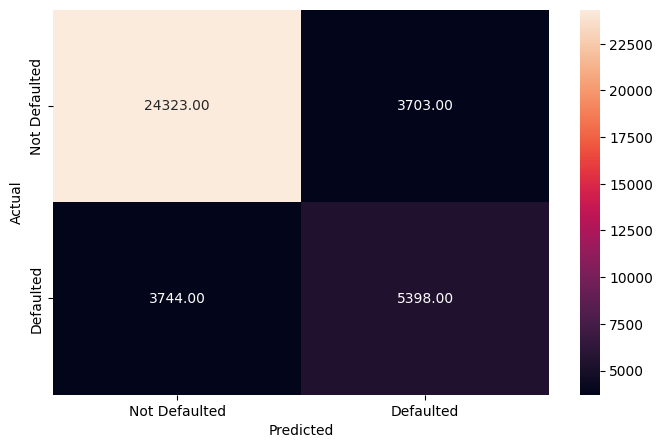

In [ ]:
pred_test_tree1 = dtree.predict(X_test)
metrics_score(y_test, pred_test_tree1)

### DTree Comments

The training results are really good, but the test results are not performing nearly as well, implying overfitting.

This is expected, as the decision tree has not been tuned yet.

# Random Forest

In [ ]:
rf_estimator = RandomForestClassifier(random_state = 1, class_weight = {0: 0.17, 1: 0.83})
rf_estimator.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, random_state=1)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     84005
         1.0       1.00      1.00      1.00     27497

    accuracy                           1.00    111502
   macro avg       1.00      1.00      1.00    111502
weighted avg       1.00      1.00      1.00    111502



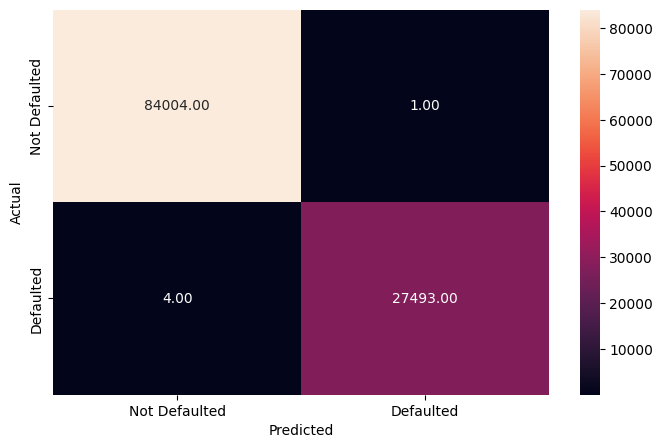

In [ ]:
train_pred_rf = rf_estimator.predict(X_train)
metrics_score(y_train, train_pred_rf)

              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     28026
         1.0       0.92      0.51      0.66      9142

    accuracy                           0.87     37168
   macro avg       0.89      0.75      0.79     37168
weighted avg       0.88      0.87      0.86     37168



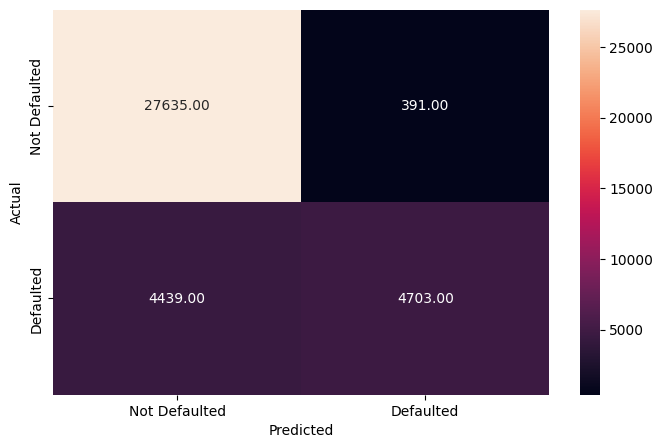

In [ ]:
test_pred_rf = rf_estimator.predict(X_test)
metrics_score(y_test, test_pred_rf)

## Tuned Random Forest

## GridSearchCV

In [ ]:
rf_estimator_tuned = RandomForestClassifier(criterion = "entropy", random_state = 1, class_weight = {0: 0.17, 1: 0.83})
params_rf = {
    "n_estimators": [200, 250],
    "max_depth": [7, 8],
    "max_features": [4, 5],
    "max_samples": [0.6, 0.9],
    "class_weight": ["balanced",{0: 0.3, 1: 0.7}]
    }

scorer = make_scorer(recall_score, pos_label = 1)


grid_obj = GridSearchCV(rf_estimator_tuned, param_grid = params_rf, scoring = scorer, cv = 5)

grid_fit = grid_obj.fit(X_train, y_train)


best_model = grid_fit.best_estimator_

print(best_model)

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, max_features=4, max_samples=0.6,
                       n_estimators=200, random_state=1)


In [ ]:
rf_estimator_tuned.fit(X_train, y_train)


RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, criterion='entropy',
                       random_state=1)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     84005
         1.0       1.00      1.00      1.00     27497

    accuracy                           1.00    111502
   macro avg       1.00      1.00      1.00    111502
weighted avg       1.00      1.00      1.00    111502



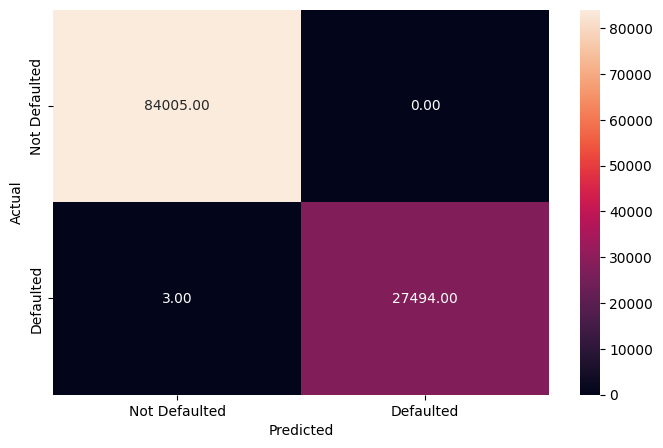

In [ ]:
pred_train_rf_tuned = rf_estimator_tuned.predict(X_train)
metrics_score(y_train, pred_train_rf_tuned)

              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     28026
         1.0       0.94      0.51      0.66      9142

    accuracy                           0.87     37168
   macro avg       0.90      0.75      0.79     37168
weighted avg       0.88      0.87      0.86     37168



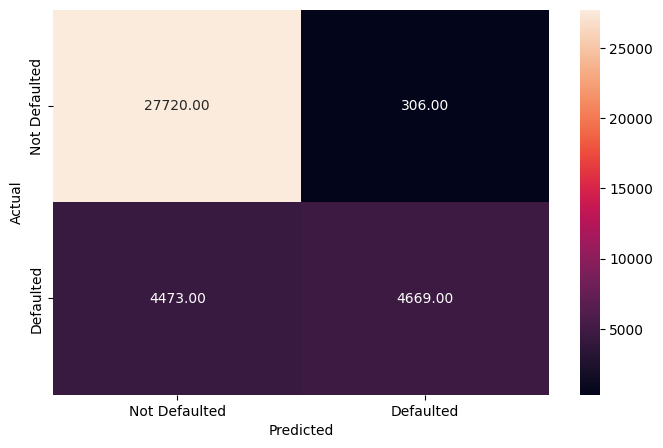

In [ ]:
pred_test_rf_tuned = rf_estimator_tuned.predict(X_test)
metrics_score(y_test, pred_test_rf_tuned)

### Feature Importance

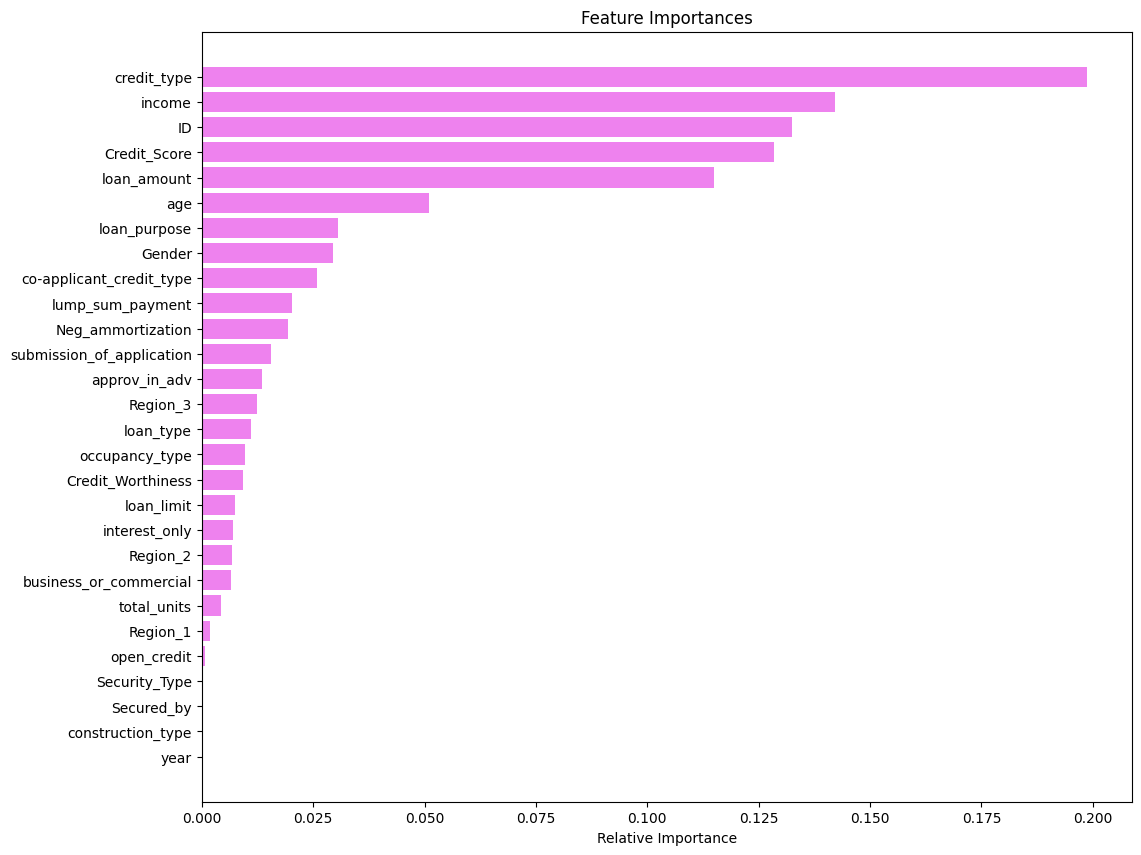

In [ ]:
importances = rf_estimator_tuned.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize = (12, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()

## Resampling training set + SMOTE + RandomizedSearchCV

In [103]:
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [108]:
# Comparing status frequency before and after SMOTE

print("Before SMOTE:")
print(y_train.value_counts(normalize=True))

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts(normalize=True))

Before SMOTE:
Status
0.0    0.753395
1.0    0.246605
Name: proportion, dtype: float64

After SMOTE:
Status
0.0    0.666669
1.0    0.333331
Name: proportion, dtype: float64


In [105]:
y_train.head()

91251     1.0
117136    0.0
23610     1.0
18637     0.0
97353     1.0
Name: Status, dtype: float64

In [ ]:
rf_estimator_tuned_smote = RandomForestClassifier(criterion = "entropy", random_state = 1, class_weight = {0: 0.17, 1: 0.83})
params_rf = {
    "n_estimators": [100, 200, 300, 450, 500],  # Increase number of trees
    "max_depth": [5, 7, 9, 12, 15, 20, 40],  # Try deeper trees
    "max_features": ["sqrt", "log2", None],  # Try different feature selection strategies
    "max_samples": [0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0],  # Sample more data per tree
    "class_weight": ["balanced", {0: 0.2, 1: 0.8}, {0: 0.3, 1: 0.7}],  # Adjust for imbalance
    "min_samples_split": [2, 5, 10],  # Control node splitting
    "min_samples_leaf": [1, 2, 5, 10],  # Avoid overfitting small nodes
    "criterion": ["gini", "entropy"]  # Try different splitting criteria
}


scorer = make_scorer(recall_score, pos_label = 1)



random_search = RandomizedSearchCV(rf_estimator_tuned_smote, param_distributions=params_rf, n_iter=50, scoring=scorer, cv=10, random_state=42, n_jobs=-1)



random_fit = random_search.fit(X_train_resampled, y_train_resampled)


best_model = random_fit.best_estimator_

print(best_model)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, max_depth=5,
                       max_features='log2', max_samples=1.0,
                       min_samples_split=10, n_estimators=200, random_state=1)


In [ ]:
rf_estimator_tuned_smote.fit(X_train_resampled, y_train_resampled)


RandomForestClassifier(class_weight={0: 0.17, 1: 0.83}, criterion='entropy',
                       random_state=1)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     84005
         1.0       1.00      1.00      1.00     42002

    accuracy                           1.00    126007
   macro avg       1.00      1.00      1.00    126007
weighted avg       1.00      1.00      1.00    126007



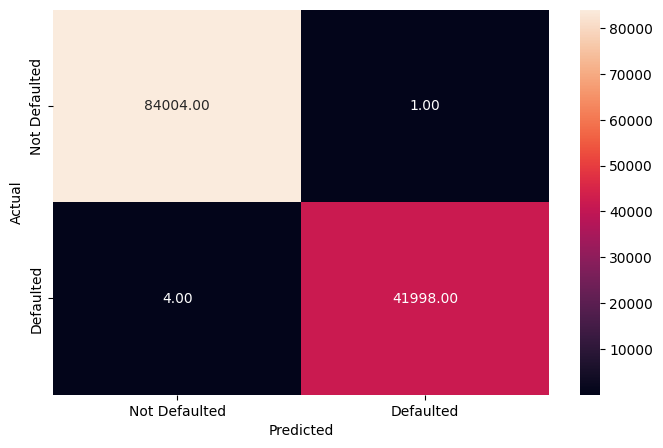

In [ ]:
pred_train_rf_tuned = rf_estimator_tuned_smote.predict(X_train_resampled)
metrics_score(y_train_resampled, pred_train_rf_tuned)

              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     28026
         1.0       0.89      0.53      0.66      9142

    accuracy                           0.87     37168
   macro avg       0.88      0.75      0.79     37168
weighted avg       0.87      0.87      0.85     37168



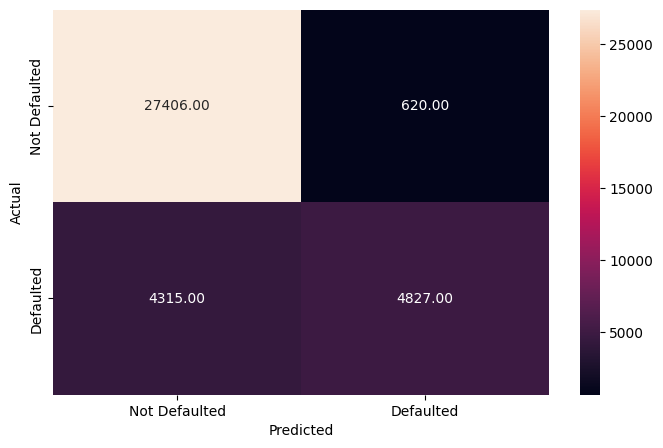

In [ ]:
pred_test_rf_tuned = rf_estimator_tuned_smote.predict(X_test)
metrics_score(y_test, pred_test_rf_tuned)

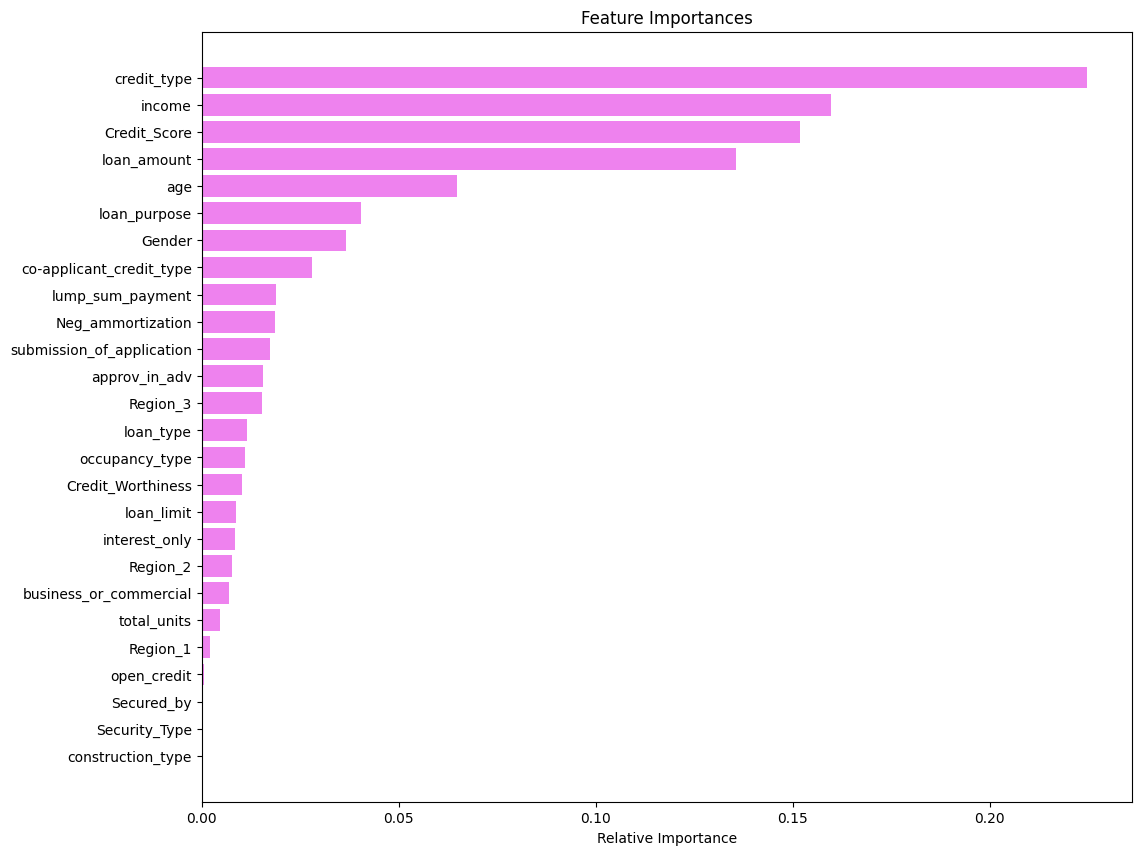

In [ ]:
importances = rf_estimator_tuned_smote.feature_importances_

indices = np.argsort(importances)

feature_names = list(X.columns)

plt.figure(figsize = (12, 10))

plt.title('Feature Importances')

plt.barh(range(len(indices)), importances[indices], color = 'violet', align = 'center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')

plt.show()